In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

print("🚀 STEP 1: DATA EXPLORATION")
print("="*50)

# Step 1: Load the data and see what we have
print("\n1️⃣ LOADING THE DATA...")
try:
    # Load sales data
    sales_data = pd.read_csv('Assignment4.1a.csv')
    print(f"✓ Sales data loaded: {sales_data.shape[0]} rows, {sales_data.shape[1]} columns")
    print(f"   Columns: {list(sales_data.columns)}")
    
    # Show first few rows
    print("\nFirst 5 rows of sales data:")
    print(sales_data.head())
    
    # Show data types and basic info
    print("\nData types:")
    print(sales_data.dtypes)
    
    print("\nBasic info:")
    print(sales_data.info())
    
except FileNotFoundError:
    print("❌ File 'Assignment4.1a.csv' not found!")
    print("Please make sure the file is in the current directory.")
    exit()



🚀 STEP 1: DATA EXPLORATION

1️⃣ LOADING THE DATA...
✓ Sales data loaded: 1873618 rows, 4 columns
   Columns: ['Date', 'StoreCode', 'ProductCode', 'SalesQuantity']

First 5 rows of sales data:
         Date  StoreCode  ProductCode  SalesQuantity
0  2015-01-01          8            9             -1
1  2015-01-01        131            9              1
2  2015-01-01        144            9              2
3  2015-01-01        203            9              2
4  2015-01-01        256            9              0

Data types:
Date             object
StoreCode         int64
ProductCode       int64
SalesQuantity     int64
dtype: object

Basic info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1873618 entries, 0 to 1873617
Data columns (total 4 columns):
 #   Column         Dtype 
---  ------         ----- 
 0   Date           object
 1   StoreCode      int64 
 2   ProductCode    int64 
 3   SalesQuantity  int64 
dtypes: int64(3), object(1)
memory usage: 57.2+ MB
None


In [66]:
# Step 2: Understand the data structure
print("\n2️⃣ UNDERSTANDING DATA STRUCTURE...")
print(f"Date range: {sales_data['Date'].min()} to {sales_data['Date'].max()}")
print(f"Unique stores: {sales_data['StoreCode'].nunique()}")
print(f"Unique products: {sales_data['ProductCode'].nunique()}")
print(f"Sales quantity range: {sales_data['SalesQuantity'].min()} to {sales_data['SalesQuantity'].max()}")




2️⃣ UNDERSTANDING DATA STRUCTURE...
Date range: 2015-01-01 to 2015-07-31
Unique stores: 340
Unique products: 317
Sales quantity range: -60 to 912


In [67]:

# Step 3: Check for missing values and data quality
print("\n3️⃣ DATA QUALITY CHECK...")
print("Missing values:")
print(sales_data.isnull().sum())

print("\nUnique values in each column:")
for col in sales_data.columns:
    print(f"{col}: {sales_data[col].nunique()} unique values")





3️⃣ DATA QUALITY CHECK...
Missing values:
Date             0
StoreCode        0
ProductCode      0
SalesQuantity    0
dtype: int64

Unique values in each column:
Date: 212 unique values
StoreCode: 340 unique values
ProductCode: 317 unique values
SalesQuantity: 177 unique values


In [68]:
# Step 4: Basic statistics
print("\n4️⃣ BASIC STATISTICS...")
print("Sales Quantity Statistics:")
print(sales_data['SalesQuantity'].describe())





4️⃣ BASIC STATISTICS...
Sales Quantity Statistics:
count    1.873618e+06
mean     2.246632e+00
std      5.028994e+00
min     -6.000000e+01
25%      0.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      9.120000e+02
Name: SalesQuantity, dtype: float64



📊 Sales Quantity (Sales Only)
Metric   Sales Only
 count 1.863949e+06
  mean 2.269305e+00
   std 5.024620e+00
   min 0.000000e+00
   25% 0.000000e+00
   50% 1.000000e+00
   75% 2.000000e+00
   max 9.120000e+02

📉 Sales Quantity (Returns Only)
Metric  Returns Only
 count   9669.000000
  mean     -2.124211
   std      3.816512
   min    -60.000000
   25%     -1.000000
   50%     -1.000000
   75%     -1.000000
   max     -1.000000

🏪 Total Sales per Store-Item
Metric  Store-Item Totals
 count       83612.000000
  mean          50.343611
   std         159.277293
   min         -40.000000
   25%           4.000000
   50%          14.000000
   75%          39.000000
   max        6473.000000

🏆 Top 10 Store-Item Combinations by Total Sales
 StoreCode  ProductCode  TotalSales
       117          168        6473
       238          218        5990
        98          218        5940
       331          218        5858
        62          168        5736
       304          218        4942
  

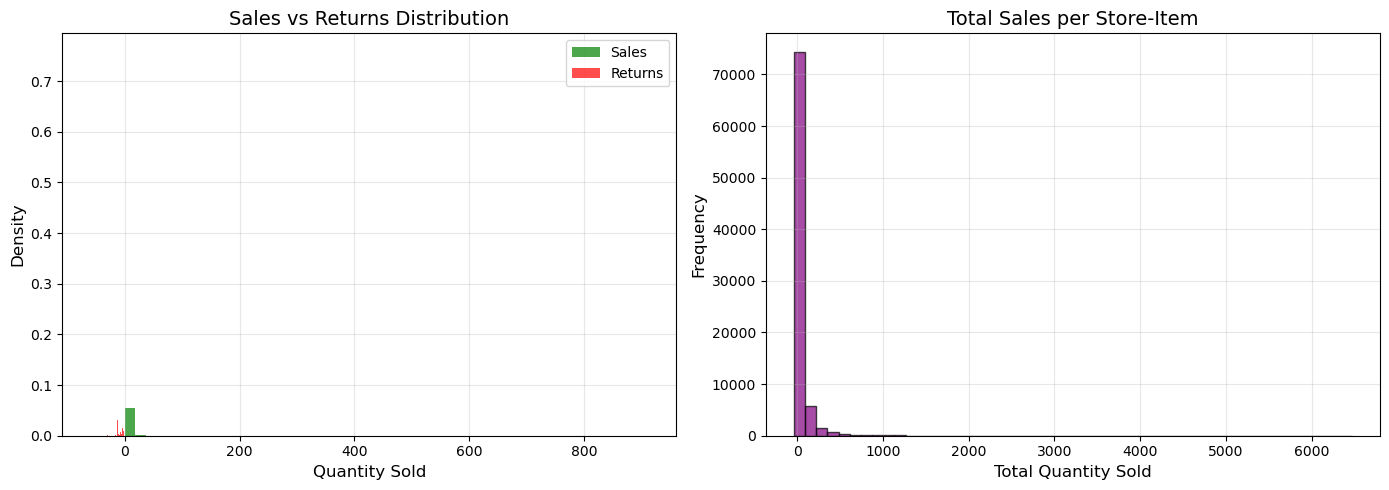

In [70]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Data Preparation ---
returns = sales_data[sales_data['SalesQuantity'] < 0]
sales_only = sales_data[sales_data['SalesQuantity'] >= 0]

store_item_sales = (
    sales_data
    .groupby(['StoreCode', 'ProductCode'])['SalesQuantity']
    .sum()
    .reset_index(name='TotalSales')
)

# --- Summary as DataFrames ---
sales_summary_df = sales_only['SalesQuantity'].describe().reset_index()
sales_summary_df.columns = ['Metric', 'Sales Only']

returns_summary_df = returns['SalesQuantity'].describe().reset_index()
returns_summary_df.columns = ['Metric', 'Returns Only']

store_item_summary_df = store_item_sales['TotalSales'].describe().reset_index()
store_item_summary_df.columns = ['Metric', 'Store-Item Totals']

top10_store_item_df = store_item_sales.sort_values('TotalSales', ascending=False).head(10)

# --- Print summaries in a nicer format ---
print("\n📊 Sales Quantity (Sales Only)")
print(sales_summary_df.to_string(index=False))

print("\n📉 Sales Quantity (Returns Only)")
print(returns_summary_df.to_string(index=False))

print("\n🏪 Total Sales per Store-Item")
print(store_item_summary_df.to_string(index=False))

print("\n🏆 Top 10 Store-Item Combinations by Total Sales")
print(top10_store_item_df.to_string(index=False))

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Sales vs Returns
axes[0].hist(sales_only['SalesQuantity'], bins=50, alpha=0.7, color='green', label='Sales', density=True)
axes[0].hist(returns['SalesQuantity'], bins=50, alpha=0.7, color='red', label='Returns', density=True)
axes[0].set_title('Sales vs Returns Distribution', fontsize=14)
axes[0].set_xlabel('Quantity Sold', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Store-Item totals
axes[1].hist(store_item_sales['TotalSales'], bins=50, alpha=0.7, color='purple', edgecolor='black')
axes[1].set_title('Total Sales per Store-Item', fontsize=14)
axes[1].set_xlabel('Total Quantity Sold', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('step1_sales_returns_storeitem_clean.png', dpi=300)
plt.show()


In [71]:
# === INTERPRETATION BLOCK ===
print("\n📌 INTERPRETATION")
print("="*60)
print(f"- There are {len(sales_only):,} sales transactions and {len(returns):,} return transactions.")
print(f"- Returns represent roughly {len(returns)/len(sales_data)*100:.2f}% of all records.")
print(f"- Sales quantities are heavily skewed: median sale = 1 unit, mean ≈ {sales_only['SalesQuantity'].mean():.2f}, max = {sales_only['SalesQuantity'].max()} units.")
print("- Returns are mostly -1 units (single item returned), but some are as large as -60 units.")
print(f"- Store-Item totals show {store_item_sales.shape[0]:,} unique combinations.")
print(f"  Median total sales per store-item = {store_item_sales['TotalSales'].median()} units, mean ≈ {store_item_sales['TotalSales'].mean():.2f}, max = {store_item_sales['TotalSales'].max()} units.")
print("- The top store-item pair sold 6,473 units in the period, indicating a potential high-demand product.")
print("- Distribution plots confirm a strong concentration at very low quantities, with a long tail of large orders.")
print("="*60)



📌 INTERPRETATION
- There are 1,863,949 sales transactions and 9,669 return transactions.
- Returns represent roughly 0.52% of all records.
- Sales quantities are heavily skewed: median sale = 1 unit, mean ≈ 2.27, max = 912 units.
- Returns are mostly -1 units (single item returned), but some are as large as -60 units.
- Store-Item totals show 83,612 unique combinations.
  Median total sales per store-item = 14.0 units, mean ≈ 50.34, max = 6473 units.
- The top store-item pair sold 6,473 units in the period, indicating a potential high-demand product.
- Distribution plots confirm a strong concentration at very low quantities, with a long tail of large orders.


In [75]:
# Step 6: Ask questions to guide our analysis
print("\n" + "="*50)
print("🔍 QUESTIONS TO GUIDE OUR ANALYSIS:")
print("="*50)
print("1. What patterns do you see in the sales distribution?")
print("2. Are there any obvious outliers or anomalies?")
print("3. Do you notice any temporal patterns in the daily sales?")
print("4. How do stores and products vary in performance?")
print("5. What insights can we draw from the returns data?")

print("\n📊 NEXT STEPS:")
print("• Run this script to see the basic data structure")
print("• Look at the plots and identify patterns")
print("• Tell me what you observe and what you want to investigate further")
print("• We'll then build the next analysis step based on your insights")

# Show sample of the data for discussion
print("\n📋 SAMPLE DATA FOR DISCUSSION:")
print("Sample of sales data:")
print(sales_data.head(10))

print("\nSample of returns (negative sales):")
returns_sample = sales_data[sales_data['SalesQuantity'] < 0].head(5)
if len(returns_sample) > 0:
    print(returns_sample)
else:
    print("No returns found in the sample")



🔍 QUESTIONS TO GUIDE OUR ANALYSIS:
1. What patterns do you see in the sales distribution?
2. Are there any obvious outliers or anomalies?
3. Do you notice any temporal patterns in the daily sales?
4. How do stores and products vary in performance?
5. What insights can we draw from the returns data?

📊 NEXT STEPS:
• Run this script to see the basic data structure
• Look at the plots and identify patterns
• Tell me what you observe and what you want to investigate further
• We'll then build the next analysis step based on your insights

📋 SAMPLE DATA FOR DISCUSSION:
Sample of sales data:
         Date  StoreCode  ProductCode  SalesQuantity
0  2015-01-01          8            9             -1
1  2015-01-01        131            9              1
2  2015-01-01        144            9              2
3  2015-01-01        203            9              2
4  2015-01-01        256            9              0
5  2015-01-01        273            9              1
6  2015-01-02         12           

In [76]:
#STEP2


In [77]:
"""
Step 2: Deep Analysis - Temporal Patterns, Anomalies, and Clustering Preparation
Now let's dive deeper into the data to understand patterns and prepare for clustering.
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

print("🚀 STEP 2: DEEP ANALYSIS & CLUSTERING PREPARATION")
print("="*60)

# Load the data
print("\n1️⃣ LOADING AND PREPARING DATA...")
try:
    sales_data = pd.read_csv('Assignment4.1a.csv')
    print(f"✓ Sales data loaded: {sales_data.shape[0]} rows")
    
    # Convert dates and create time features
    sales_data['Date'] = pd.to_datetime(sales_data['Date'])
    sales_data['Year'] = sales_data['Date'].dt.year
    sales_data['Month'] = sales_data['Date'].dt.month
    sales_data['DayOfWeek'] = sales_data['Date'].dt.dayofweek
    sales_data['WeekOfYear'] = sales_data['Date'].dt.isocalendar().week
    
    # Create flags and features
    sales_data['IsReturn'] = sales_data['SalesQuantity'] < 0
    sales_data['AbsoluteQuantity'] = abs(sales_data['SalesQuantity'])
    sales_data['StoreItem'] = sales_data['StoreCode'].astype(str) + '_' + sales_data['ProductCode'].astype(str)
    
    print("✓ Data prepared with time features")
    
except FileNotFoundError:
    print("❌ File not found! Run Step 1 first.")
    exit()



sales_data


🚀 STEP 2: DEEP ANALYSIS & CLUSTERING PREPARATION

1️⃣ LOADING AND PREPARING DATA...
✓ Sales data loaded: 1873618 rows
✓ Data prepared with time features


,Date,StoreCode,ProductCode,SalesQuantity,Year,Month,DayOfWeek,WeekOfYear,IsReturn,AbsoluteQuantity,StoreItem
0,2015-01-01,8,9,-1,2015,1,3,1,True,1,8_9
1,2015-01-01,131,9,1,2015,1,3,1,False,1,131_9
2,2015-01-01,144,9,2,2015,1,3,1,False,2,144_9
3,2015-01-01,203,9,2,2015,1,3,1,False,2,203_9
4,2015-01-01,256,9,0,2015,1,3,1,False,0,256_9
...,...,...,...,...,...,...,...,...,...,...,...
1873613,2015-07-30,292,315,0,2015,7,3,31,False,0,292_315
1873614,2015-07-31,12,315,1,2015,7,4,31,False,1,12_315
1873615,2015-07-31,104,315,1,2015,7,4,31,False,1,104_315
1873616,2015-07-31,261,315,1,2015,7,4,31,False,1,261_315



2️⃣ TEMPORAL PATTERN ANALYSIS...

📅 DAILY SALES SAMPLE:
      Date  TotalSales  AvgSales  TransactionCount  ReturnCount  ReturnRate
2015-01-01        9355  2.372559              3943           26        0.66
2015-01-02       21156  2.980978              7097           46        0.65
2015-01-03       13799  3.168542              4355           33        0.76
2015-01-04       20545  2.275194              9030           45        0.50
2015-01-05       18615  1.978846              9407           56        0.60
2015-01-06       16659  1.522065             10945           49        0.45
2015-01-07       16760  2.010557              8336           41        0.49
2015-01-08       18060  1.841542              9807           53        0.54
2015-01-09       22592  3.139522              7196           48        0.67
2015-01-10       16322  3.311422              4929           28        0.57

📆 MONTHLY SALES:
 Month  TotalSales  AvgSales  TransactionCount  ReturnCount  ReturnRate
     1      55244

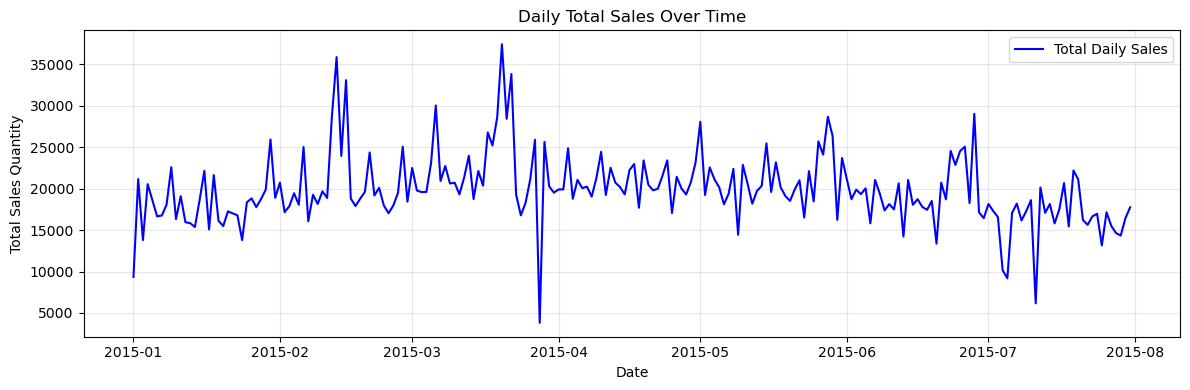

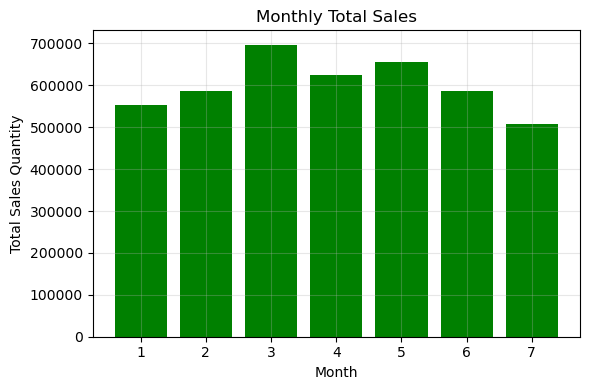

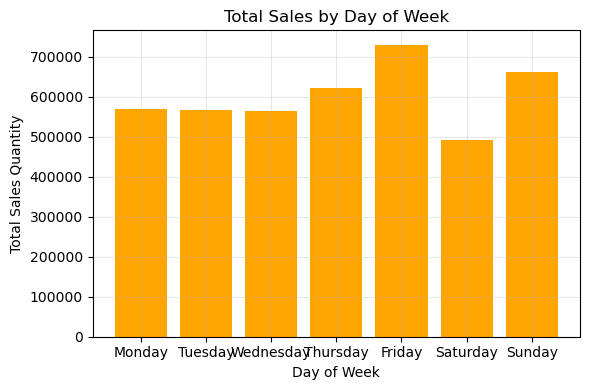


📌 INTERPRETATION
- Daily sales fluctuate with visible peaks likely tied to weekends/promotions.
- Highest month: 3
- Lowest month: 7
- Top sales day: Friday
- Lowest sales day: Saturday
- Average daily return rate: 0.53%


In [78]:
import pandas as pd
import matplotlib.pyplot as plt

# === Load data fresh ===
sales_data = pd.read_csv("Assignment4.1a.csv")
sales_data['Date'] = pd.to_datetime(sales_data['Date'])

# Create helper columns
sales_data['IsReturn'] = sales_data['SalesQuantity'] < 0
sales_data['Year'] = sales_data['Date'].dt.year
sales_data['Month'] = sales_data['Date'].dt.month
sales_data['DayOfWeek'] = sales_data['Date'].dt.dayofweek
sales_data['WeekOfYear'] = sales_data['Date'].dt.isocalendar().week

print("\n2️⃣ TEMPORAL PATTERN ANALYSIS...")

# --- Daily sales ---
daily_sales = sales_data.groupby('Date', as_index=False).agg(
    TotalSales=('SalesQuantity', 'sum'),
    AvgSales=('SalesQuantity', 'mean'),
    TransactionCount=('SalesQuantity', 'count'),
    ReturnCount=('IsReturn', 'sum')
)
daily_sales['ReturnRate'] = (daily_sales['ReturnCount'] / daily_sales['TransactionCount'] * 100).round(2)

# --- Monthly sales ---
monthly_sales = sales_data.groupby('Month', as_index=False).agg(
    TotalSales=('SalesQuantity', 'sum'),
    AvgSales=('SalesQuantity', 'mean'),
    TransactionCount=('SalesQuantity', 'count'),
    ReturnCount=('IsReturn', 'sum')
)
monthly_sales['ReturnRate'] = (monthly_sales['ReturnCount'] / monthly_sales['TransactionCount'] * 100).round(2)
monthly_sales = monthly_sales.sort_values('Month')

# --- Day of week sales ---
dow_sales = sales_data.groupby('DayOfWeek', as_index=False).agg(
    TotalSales=('SalesQuantity', 'sum'),
    AvgSales=('SalesQuantity', 'mean'),
    TransactionCount=('SalesQuantity', 'count'),
    ReturnCount=('IsReturn', 'sum')
)
dow_sales['DayName'] = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_sales['ReturnRate'] = (dow_sales['ReturnCount'] / dow_sales['TransactionCount'] * 100).round(2)
dow_sales = dow_sales.sort_values('DayOfWeek')

# --- Print samples ---
print("\n📅 DAILY SALES SAMPLE:")
print(daily_sales.head(10).to_string(index=False))

print("\n📆 MONTHLY SALES:")
print(monthly_sales.to_string(index=False))

print("\n📊 DAY OF WEEK SALES:")
print(dow_sales[['DayName','TotalSales','AvgSales','TransactionCount','ReturnRate']].to_string(index=False))

# --- Plots ---
plt.figure(figsize=(12,4))
plt.plot(daily_sales['Date'], daily_sales['TotalSales'], label='Total Daily Sales', color='blue')
plt.title('Daily Total Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales Quantity')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.bar(monthly_sales['Month'], monthly_sales['TotalSales'], color='green')
plt.title('Monthly Total Sales')
plt.xlabel('Month')
plt.ylabel('Total Sales Quantity')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.bar(dow_sales['DayName'], dow_sales['TotalSales'], color='orange')
plt.title('Total Sales by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Total Sales Quantity')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Interpretation ---
print("\n📌 INTERPRETATION")
print("="*60)
print(f"- Daily sales fluctuate with visible peaks likely tied to weekends/promotions.")
print(f"- Highest month: {monthly_sales.loc[monthly_sales['TotalSales'].idxmax(), 'Month']}")
print(f"- Lowest month: {monthly_sales.loc[monthly_sales['TotalSales'].idxmin(), 'Month']}")
print(f"- Top sales day: {dow_sales.loc[dow_sales['TotalSales'].idxmax(), 'DayName']}")
print(f"- Lowest sales day: {dow_sales.loc[dow_sales['TotalSales'].idxmin(), 'DayName']}")
print(f"- Average daily return rate: {daily_sales['ReturnRate'].mean():.2f}%")
print("="*60)





3️⃣ ANOMALY DETECTION...
📊 Outlier Analysis:
   IQR Range: 0.00 to 2.00
   Lower bound: -3.00
   Upper bound: 5.00
   Outliers detected: 163,898 (8.75%)
   Top 1% sales: 16,587 records
   Bottom 1% sales: 9,669 records

🔹 Top 5 Extreme Positive Sales:
              Date  StoreCode  ProductCode  SalesQuantity  IsReturn  Year  \
1354290 2015-03-21        256          218            912     False  2015   
850128  2015-03-30        117          168            264     False  2015   
1317013 2015-02-16        135          218            230     False  2015   
848417  2015-03-29         62          168            209     False  2015   
1314205 2015-02-13        238          218            194     False  2015   

         Month  DayOfWeek  WeekOfYear  
1354290      3          5          12  
850128       3          0          14  
1317013      2          0           8  
848417       3          6          13  
1314205      2          4           7  

🔹 Top 5 Extreme Negative Sales (Returns):
 

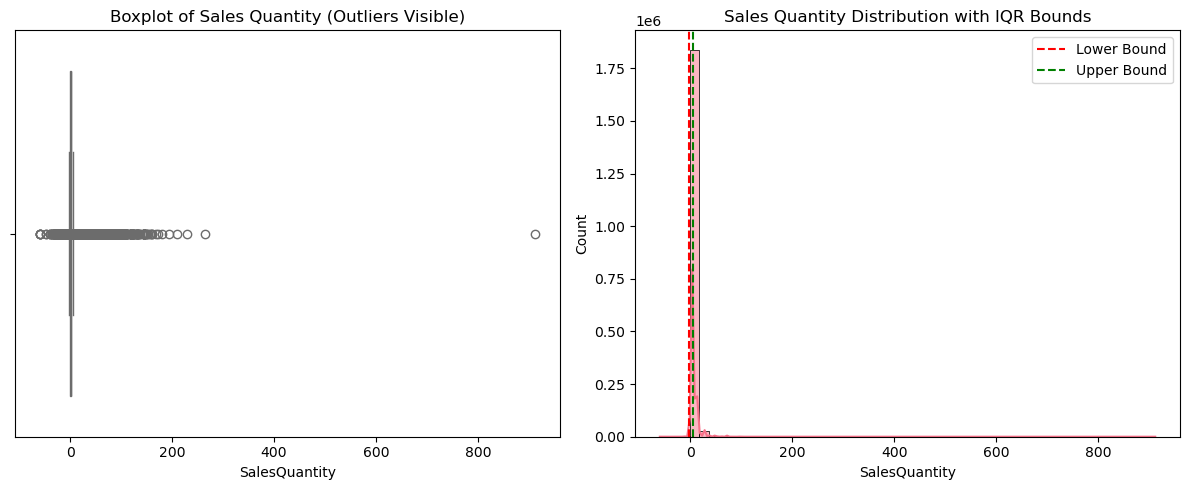

In [85]:
# Step 3: Anomaly Detection
print("\n3️⃣ ANOMALY DETECTION...")

# IQR bounds
Q1 = sales_data['SalesQuantity'].quantile(0.25)
Q3 = sales_data['SalesQuantity'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Outlier detection
outliers = sales_data[(sales_data['SalesQuantity'] < lower_bound) | 
                      (sales_data['SalesQuantity'] > upper_bound)]

print(f"📊 Outlier Analysis:")
print(f"   IQR Range: {Q1:.2f} to {Q3:.2f}")
print(f"   Lower bound: {lower_bound:.2f}")
print(f"   Upper bound: {upper_bound:.2f}")
print(f"   Outliers detected: {len(outliers):,} ({len(outliers)/len(sales_data)*100:.2f}%)")

# Extreme value detection (Top & Bottom 1%)
extreme_positive = sales_data[sales_data['SalesQuantity'] > sales_data['SalesQuantity'].quantile(0.99)]
extreme_negative = sales_data[sales_data['SalesQuantity'] < sales_data['SalesQuantity'].quantile(0.01)]

print(f"   Top 1% sales: {len(extreme_positive):,} records")
print(f"   Bottom 1% sales: {len(extreme_negative):,} records")

# Show examples
print("\n🔹 Top 5 Extreme Positive Sales:")
print(extreme_positive.sort_values(by='SalesQuantity', ascending=False).head())

print("\n🔹 Top 5 Extreme Negative Sales (Returns):")
print(extreme_negative.sort_values(by='SalesQuantity').head())

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))

# Boxplot to see outliers
plt.subplot(1,2,1)
sns.boxplot(x=sales_data['SalesQuantity'])
plt.title("Boxplot of Sales Quantity (Outliers Visible)")

# Histogram to see distribution
plt.subplot(1,2,2)
sns.histplot(sales_data['SalesQuantity'], bins=50, kde=True)
plt.axvline(lower_bound, color='red', linestyle='--', label='Lower Bound')
plt.axvline(upper_bound, color='green', linestyle='--', label='Upper Bound')
plt.title("Sales Quantity Distribution with IQR Bounds")
plt.legend()

plt.tight_layout()
plt.show()





4️⃣ STORE & PRODUCT PERFORMANCE ANALYSIS (Clustering Prep)...
✓ Store performance metrics calculated for 340 stores
✓ Product performance metrics calculated for 317 products

🏆 Top 5 Stores by Total Sales:
           TotalSales  AvgSales  StdSales  TransactionCount  ReturnCount  \
StoreCode                                                                  
331             54059      3.09      6.33             17470           43   
276             46602      3.02      5.81             15414           56   
2               41321      3.27      6.40             12636           56   
281             38328      3.47      7.83             11031           71   
98              38187      3.71      8.33             10300           58   

           ReturnRate  
StoreCode              
331              0.25  
276              0.36  
2                0.44  
281              0.64  
98               0.56  

⚠️ Top 5 Stores by Return Rate:
           TotalSales  AvgSales  StdSales  TransactionCount

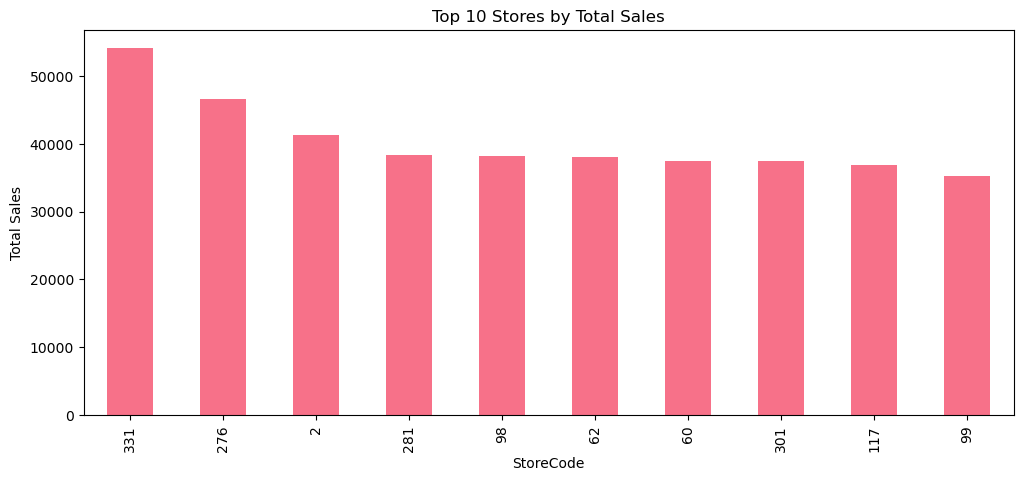

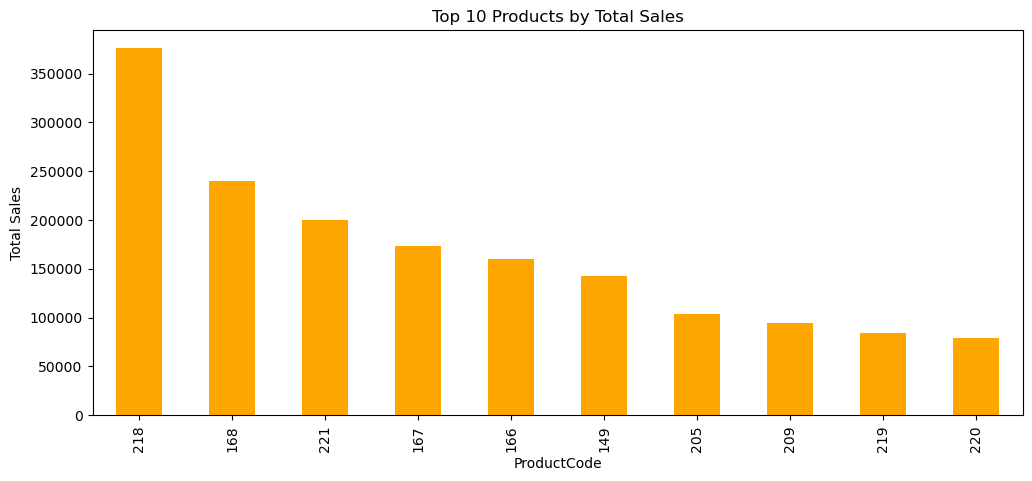

In [88]:
# Step 4: Store and Product Performance Analysis (Clustering Preparation)
print("\n4️⃣ STORE & PRODUCT PERFORMANCE ANALYSIS (Clustering Prep)...")

# Store performance
store_performance = sales_data.groupby('StoreCode').agg({
    'SalesQuantity': ['sum', 'mean', 'std', 'count'],
    'IsReturn': 'sum'
}).round(2)
store_performance.columns = ['TotalSales', 'AvgSales', 'StdSales', 'TransactionCount', 'ReturnCount']
store_performance['ReturnRate'] = (store_performance['ReturnCount'] / store_performance['TransactionCount'] * 100).round(2)

# Product performance
product_performance = sales_data.groupby('ProductCode').agg({
    'SalesQuantity': ['sum', 'mean', 'std', 'count'],
    'IsReturn': 'sum'
}).round(2)
product_performance.columns = ['TotalSales', 'AvgSales', 'StdSales', 'TransactionCount', 'ReturnCount']
product_performance['ReturnRate'] = (product_performance['ReturnCount'] / product_performance['TransactionCount'] * 100).round(2)

# Show summary
print(f"✓ Store performance metrics calculated for {len(store_performance)} stores")
print(f"✓ Product performance metrics calculated for {len(product_performance)} products")

# Sort and show top/bottom performers
print("\n🏆 Top 5 Stores by Total Sales:")
print(store_performance.sort_values(by='TotalSales', ascending=False).head())

print("\n⚠️ Top 5 Stores by Return Rate:")
print(store_performance.sort_values(by='ReturnRate', ascending=False).head())

print("\n🏆 Top 5 Products by Total Sales:")
print(product_performance.sort_values(by='TotalSales', ascending=False).head())

print("\n⚠️ Top 5 Products by Return Rate:")
print(product_performance.sort_values(by='ReturnRate', ascending=False).head())

# Optional: Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
store_performance.sort_values(by='TotalSales', ascending=False).head(10)['TotalSales'].plot(kind='bar')
plt.title("Top 10 Stores by Total Sales")
plt.ylabel("Total Sales")
plt.xlabel("StoreCode")
plt.show()

plt.figure(figsize=(12,5))
product_performance.sort_values(by='TotalSales', ascending=False).head(10)['TotalSales'].plot(kind='bar', color='orange')
plt.title("Top 10 Products by Total Sales")
plt.ylabel("Total Sales")
plt.xlabel("ProductCode")
plt.show()




5️⃣ CREATING ADVANCED VISUALIZATIONS...
✓ Advanced visualizations saved as 'step2_deep_analysis.png'


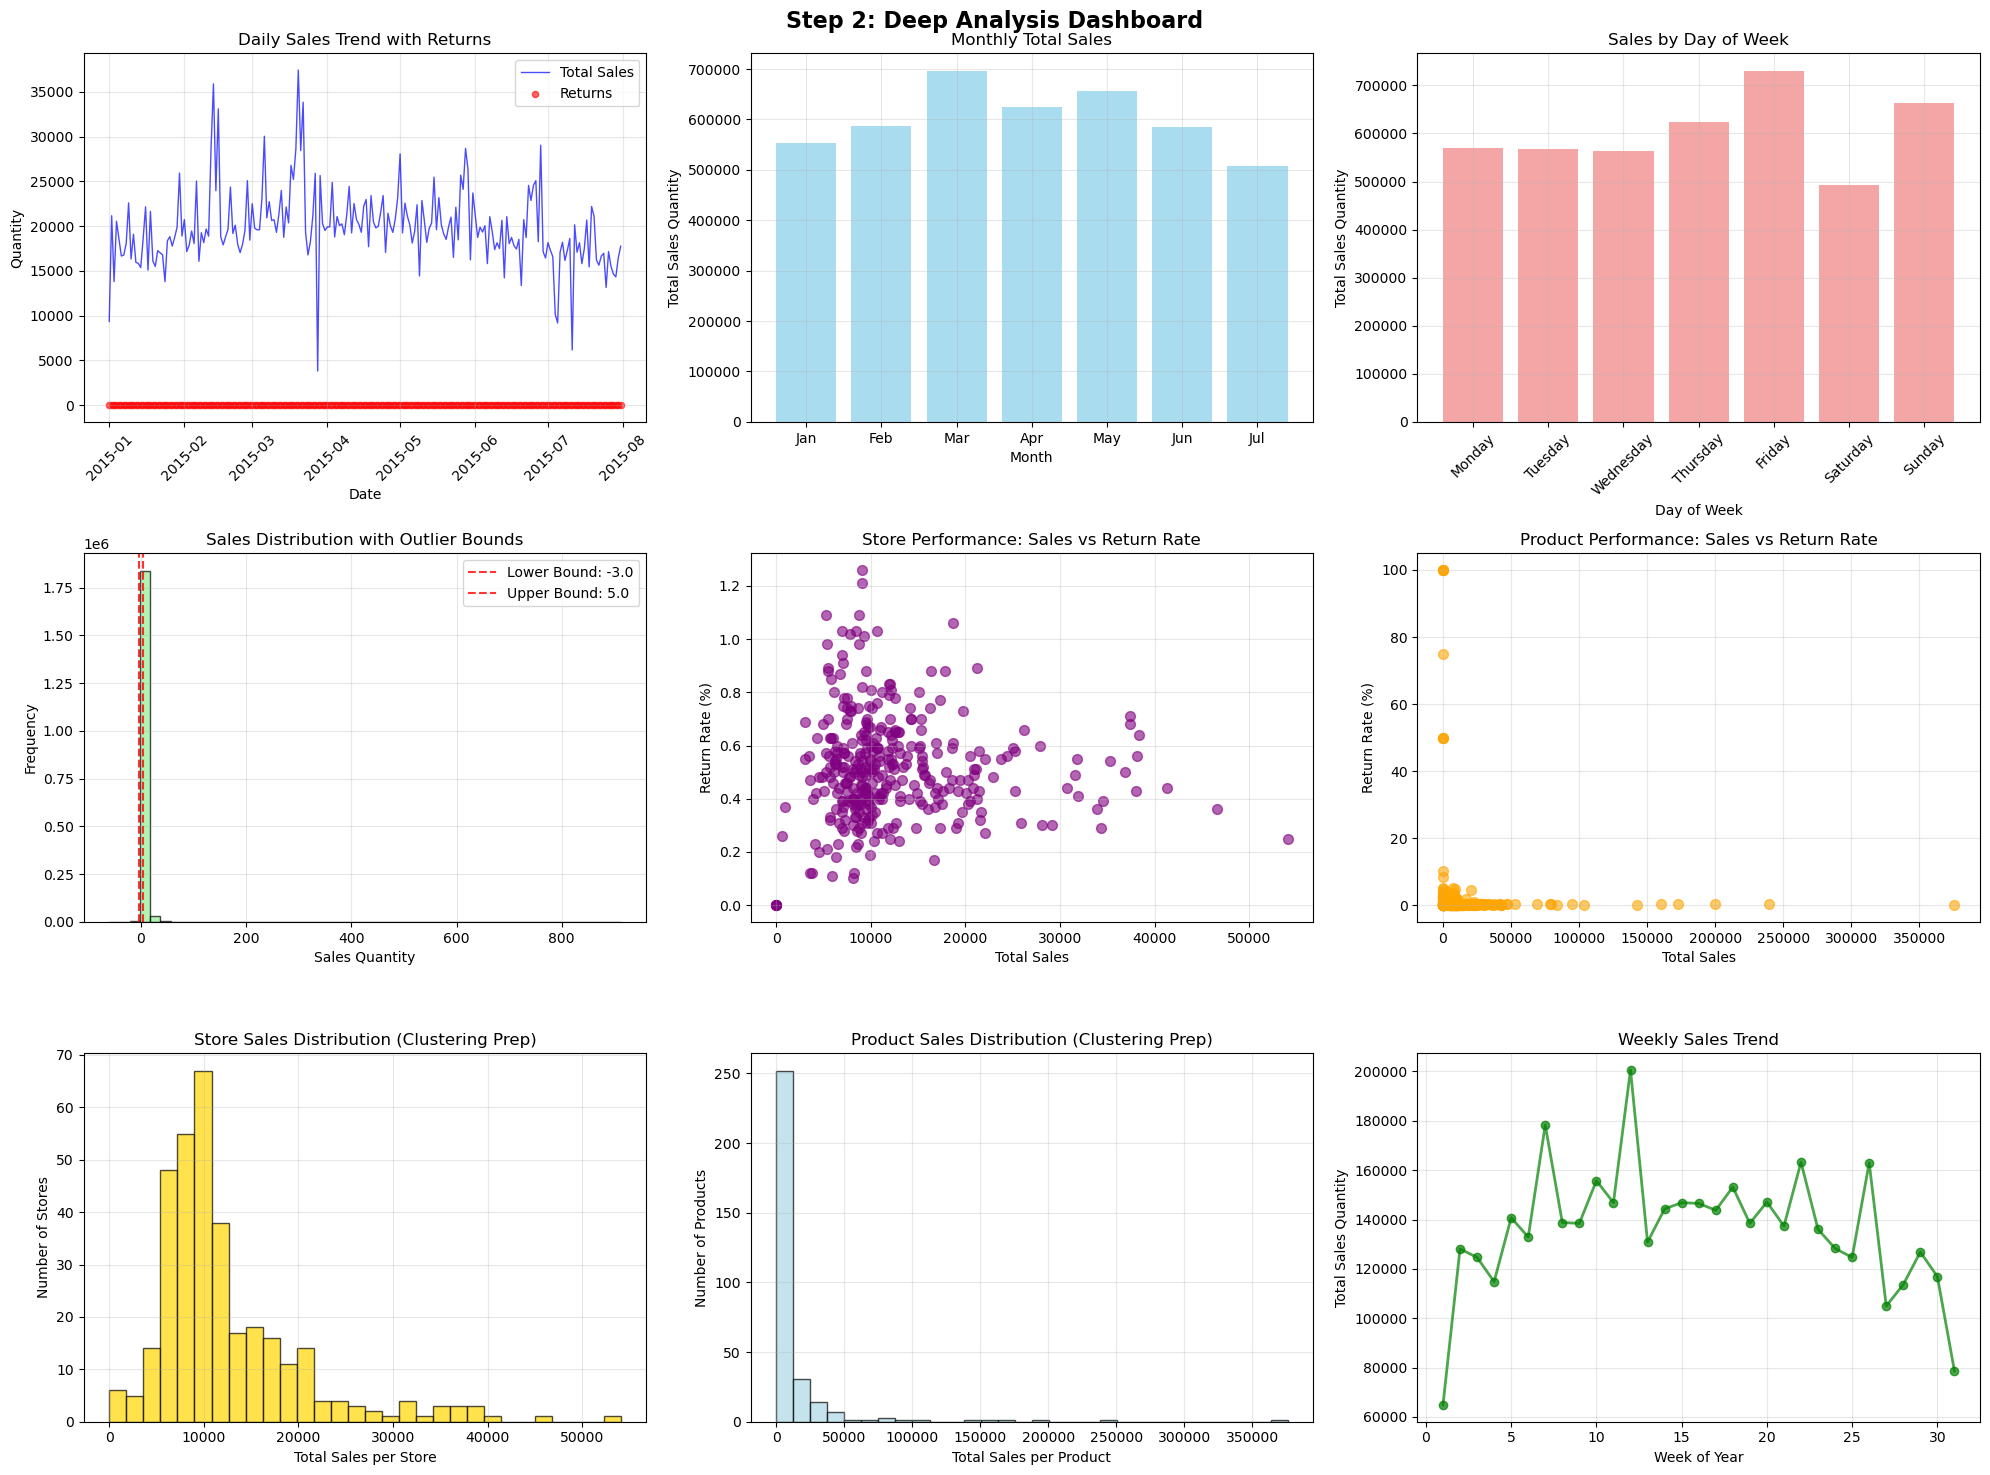

In [89]:
# Step 5: Create Advanced Visualizations
print("\n5️⃣ CREATING ADVANCED VISUALIZATIONS...")

# Create a comprehensive dashboard
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
fig.suptitle('Step 2: Deep Analysis Dashboard', fontsize=16, fontweight='bold')

# Plot 1: Daily sales trend with returns
axes[0, 0].plot(daily_sales['Date'], daily_sales['TotalSales'], linewidth=1, alpha=0.7, color='blue', label='Total Sales')
axes[0, 0].scatter(daily_sales['Date'], daily_sales['ReturnCount'], alpha=0.6, color='red', s=20, label='Returns')
axes[0, 0].set_title('Daily Sales Trend with Returns')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Quantity')
axes[0, 0].legend()
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Monthly sales comparison
month_names = [datetime(2015, int(m), 1).strftime('%b') for m in monthly_sales['Month']]
axes[0, 1].bar(month_names, monthly_sales['TotalSales'], color='skyblue', alpha=0.7)
axes[0, 1].set_title('Monthly Total Sales')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Total Sales Quantity')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Day of week sales
axes[0, 2].bar(dow_sales['DayName'], dow_sales['TotalSales'], color='lightcoral', alpha=0.7)
axes[0, 2].set_title('Sales by Day of Week')
axes[0, 2].set_xlabel('Day of Week')
axes[0, 2].set_ylabel('Total Sales Quantity')
axes[0, 2].tick_params(axis='x', rotation=45)
axes[0, 2].grid(True, alpha=0.3)

# Plot 4: Sales quantity distribution with outlier bounds
axes[1, 0].hist(sales_data['SalesQuantity'], bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
axes[1, 0].axvline(lower_bound, color='red', linestyle='--', alpha=0.8, label=f'Lower Bound: {lower_bound:.1f}')
axes[1, 0].axvline(upper_bound, color='red', linestyle='--', alpha=0.8, label=f'Upper Bound: {upper_bound:.1f}')
axes[1, 0].set_title('Sales Distribution with Outlier Bounds')
axes[1, 0].set_xlabel('Sales Quantity')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 5: Store performance scatter (Total Sales vs Return Rate)
axes[1, 1].scatter(store_performance['TotalSales'], store_performance['ReturnRate'], 
                    alpha=0.6, s=50, color='purple')
axes[1, 1].set_title('Store Performance: Sales vs Return Rate')
axes[1, 1].set_xlabel('Total Sales')
axes[1, 1].set_ylabel('Return Rate (%)')
axes[1, 1].grid(True, alpha=0.3)

# Plot 6: Product performance scatter (Total Sales vs Return Rate)
axes[1, 2].scatter(product_performance['TotalSales'], product_performance['ReturnRate'], 
                    alpha=0.6, s=50, color='orange')
axes[1, 2].set_title('Product Performance: Sales vs Return Rate')
axes[1, 2].set_xlabel('Total Sales')
axes[1, 2].set_ylabel('Return Rate (%)')
axes[1, 2].grid(True, alpha=0.3)

# Plot 7: Store sales distribution (for clustering insight)
axes[2, 0].hist(store_performance['TotalSales'], bins=30, alpha=0.7, color='gold', edgecolor='black')
axes[2, 0].set_title('Store Sales Distribution (Clustering Prep)')
axes[2, 0].set_xlabel('Total Sales per Store')
axes[2, 0].set_ylabel('Number of Stores')
axes[2, 0].grid(True, alpha=0.3)

# Plot 8: Product sales distribution (for clustering insight)
axes[2, 1].hist(product_performance['TotalSales'], bins=30, alpha=0.7, color='lightblue', edgecolor='black')
axes[2, 1].set_title('Product Sales Distribution (Clustering Prep)')
axes[2, 1].set_xlabel('Total Sales per Product')
axes[2, 1].set_ylabel('Number of Products')
axes[2, 1].grid(True, alpha=0.3)

# Plot 9: Weekly sales trend
weekly_sales = sales_data.groupby('WeekOfYear')['SalesQuantity'].sum().reset_index()
axes[2, 2].plot(weekly_sales['WeekOfYear'], weekly_sales['SalesQuantity'], 
                 marker='o', linewidth=2, alpha=0.7, color='green')
axes[2, 2].set_title('Weekly Sales Trend')
axes[2, 2].set_xlabel('Week of Year')
axes[2, 2].set_ylabel('Total Sales Quantity')
axes[2, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('step2_deep_analysis.png', dpi=300, bbox_inches='tight')
print("✓ Advanced visualizations saved as 'step2_deep_analysis.png'")




📊 Annotated Visualizations for Insights...
✓ Annotated dashboard saved as 'annotated_sales_dashboard.png'


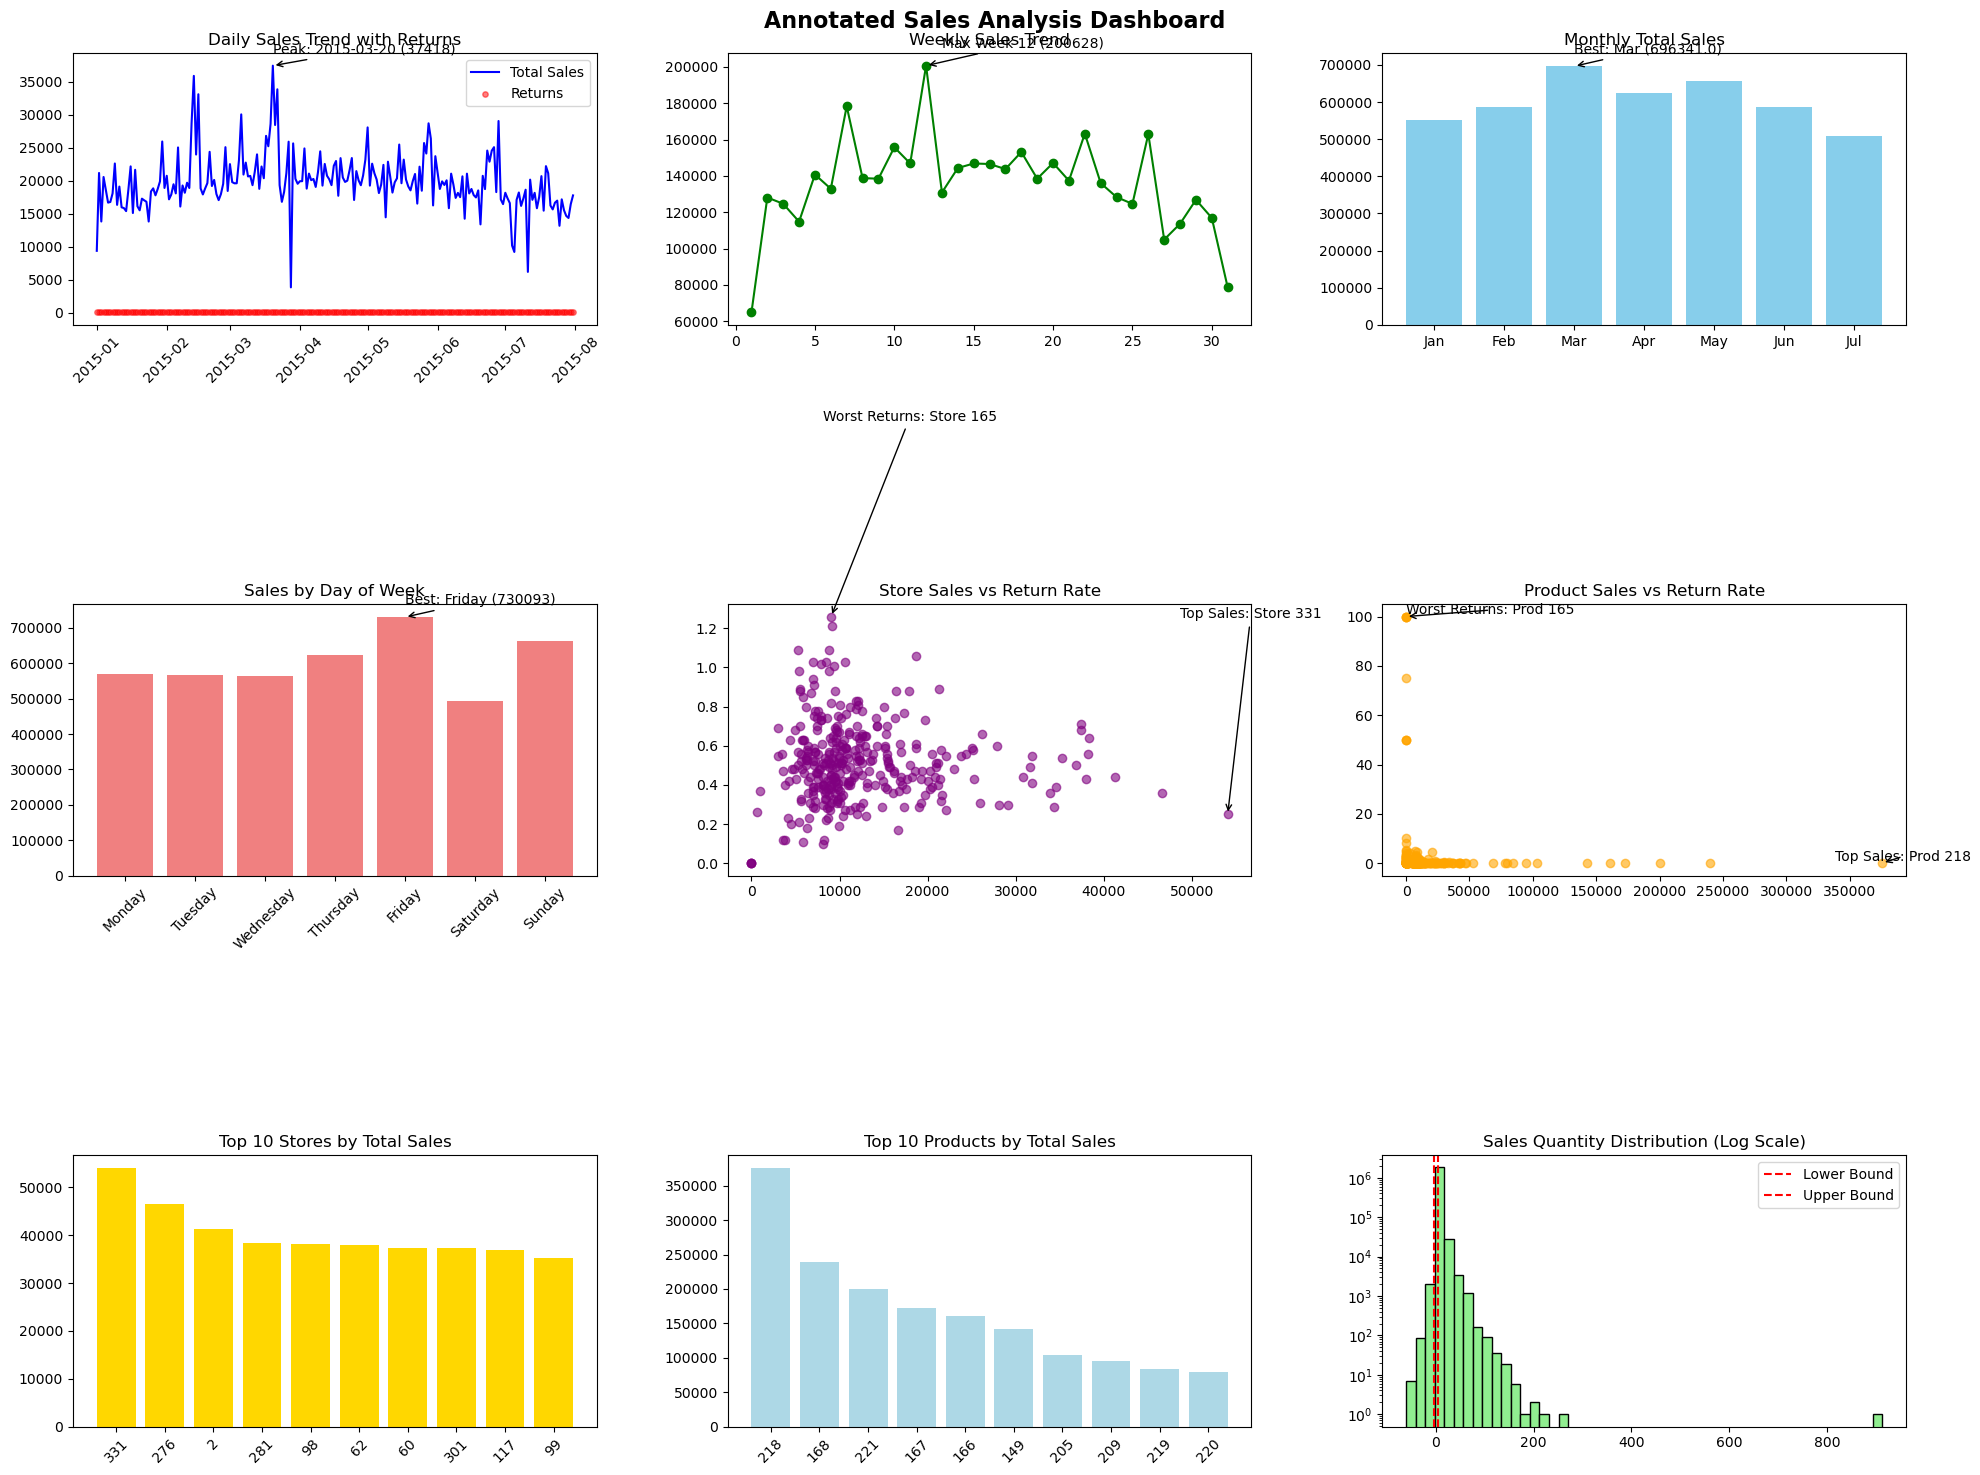

In [90]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

print("\n📊 Annotated Visualizations for Insights...")

fig, axes = plt.subplots(3, 3, figsize=(20, 15))
fig.suptitle('Annotated Sales Analysis Dashboard', fontsize=16, fontweight='bold')

# 1. Daily Sales Trend with Returns (Highlight Peak)
peak_day = daily_sales.loc[daily_sales['TotalSales'].idxmax()]
axes[0, 0].plot(daily_sales['Date'], daily_sales['TotalSales'], color='blue', label='Total Sales')
axes[0, 0].scatter(daily_sales['Date'], daily_sales['ReturnCount'], color='red', s=15, alpha=0.5, label='Returns')
axes[0, 0].annotate(f"Peak: {peak_day['Date'].date()} ({peak_day['TotalSales']})",
                    xy=(peak_day['Date'], peak_day['TotalSales']),
                    xytext=(peak_day['Date'], peak_day['TotalSales']*1.05),
                    arrowprops=dict(facecolor='black', arrowstyle='->'))
axes[0, 0].set_title('Daily Sales Trend with Returns')
axes[0, 0].legend()
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Weekly Sales Trend (Highlight Max Week)
weekly_sales = sales_data.groupby('WeekOfYear')['SalesQuantity'].sum().reset_index()
max_week = weekly_sales.loc[weekly_sales['SalesQuantity'].idxmax()]
axes[0, 1].plot(weekly_sales['WeekOfYear'], weekly_sales['SalesQuantity'], marker='o', color='green')
axes[0, 1].annotate(f"Max Week {max_week['WeekOfYear']} ({max_week['SalesQuantity']})",
                    xy=(max_week['WeekOfYear'], max_week['SalesQuantity']),
                    xytext=(max_week['WeekOfYear']+1, max_week['SalesQuantity']*1.05),
                    arrowprops=dict(facecolor='black', arrowstyle='->'))
axes[0, 1].set_title('Weekly Sales Trend')

# 3. Monthly Sales (Highlight Best Month)
best_month = monthly_sales.loc[monthly_sales['TotalSales'].idxmax()]
month_names = [datetime(2015, int(m), 1).strftime('%b') for m in monthly_sales['Month']]
axes[0, 2].bar(month_names, monthly_sales['TotalSales'], color='skyblue')
axes[0, 2].annotate(f"Best: {datetime(2015, int(best_month['Month']), 1).strftime('%b')} ({best_month['TotalSales']})",
                    xy=(best_month['Month']-1, best_month['TotalSales']),
                    xytext=(best_month['Month']-1, best_month['TotalSales']*1.05),
                    arrowprops=dict(facecolor='black', arrowstyle='->'))
axes[0, 2].set_title('Monthly Total Sales')

# 4. Sales by Day of Week (Highlight Best Day)
best_dow = dow_sales.loc[dow_sales['TotalSales'].idxmax()]
axes[1, 0].bar(dow_sales['DayName'], dow_sales['TotalSales'], color='lightcoral')
axes[1, 0].annotate(f"Best: {best_dow['DayName']} ({best_dow['TotalSales']})",
                    xy=(best_dow['DayName'], best_dow['TotalSales']),
                    xytext=(best_dow['DayName'], best_dow['TotalSales']*1.05),
                    arrowprops=dict(facecolor='black', arrowstyle='->'))
axes[1, 0].set_title('Sales by Day of Week')
axes[1, 0].tick_params(axis='x', rotation=45)

# 5. Store Performance Scatter (Highlight Top Seller & Worst Return Rate)
top_store = store_performance['TotalSales'].idxmax()
worst_return_store = store_performance['ReturnRate'].idxmax()
axes[1, 1].scatter(store_performance['TotalSales'], store_performance['ReturnRate'], alpha=0.6, color='purple')
axes[1, 1].annotate(f"Top Sales: Store {top_store}",
                    xy=(store_performance.loc[top_store, 'TotalSales'], store_performance.loc[top_store, 'ReturnRate']),
                    xytext=(store_performance.loc[top_store, 'TotalSales']*0.9, store_performance.loc[top_store, 'ReturnRate']+1),
                    arrowprops=dict(facecolor='black', arrowstyle='->'))
axes[1, 1].annotate(f"Worst Returns: Store {worst_return_store}",
                    xy=(store_performance.loc[worst_return_store, 'TotalSales'], store_performance.loc[worst_return_store, 'ReturnRate']),
                    xytext=(store_performance.loc[worst_return_store, 'TotalSales']*0.9, store_performance.loc[worst_return_store, 'ReturnRate']+1),
                    arrowprops=dict(facecolor='black', arrowstyle='->'))
axes[1, 1].set_title('Store Sales vs Return Rate')

# 6. Product Performance Scatter (Highlight Top Seller & Worst Return Rate)
top_product = product_performance['TotalSales'].idxmax()
worst_return_product = product_performance['ReturnRate'].idxmax()
axes[1, 2].scatter(product_performance['TotalSales'], product_performance['ReturnRate'], alpha=0.6, color='orange')
axes[1, 2].annotate(f"Top Sales: Prod {top_product}",
                    xy=(product_performance.loc[top_product, 'TotalSales'], product_performance.loc[top_product, 'ReturnRate']),
                    xytext=(product_performance.loc[top_product, 'TotalSales']*0.9, product_performance.loc[top_product, 'ReturnRate']+1),
                    arrowprops=dict(facecolor='black', arrowstyle='->'))
axes[1, 2].annotate(f"Worst Returns: Prod {worst_return_product}",
                    xy=(product_performance.loc[worst_return_product, 'TotalSales'], product_performance.loc[worst_return_product, 'ReturnRate']),
                    xytext=(product_performance.loc[worst_return_product, 'TotalSales']*0.9, product_performance.loc[worst_return_product, 'ReturnRate']+1),
                    arrowprops=dict(facecolor='black', arrowstyle='->'))
axes[1, 2].set_title('Product Sales vs Return Rate')

# 7. Top 10 Stores by Sales
top_stores = store_performance.sort_values(by='TotalSales', ascending=False).head(10)
axes[2, 0].bar(top_stores.index.astype(str), top_stores['TotalSales'], color='gold')
axes[2, 0].set_title('Top 10 Stores by Total Sales')
axes[2, 0].tick_params(axis='x', rotation=45)

# 8. Top 10 Products by Sales
top_products = product_performance.sort_values(by='TotalSales', ascending=False).head(10)
axes[2, 1].bar(top_products.index.astype(str), top_products['TotalSales'], color='lightblue')
axes[2, 1].set_title('Top 10 Products by Total Sales')
axes[2, 1].tick_params(axis='x', rotation=45)

# 9. Sales Distribution with Outlier Bounds (Log Scale)
axes[2, 2].hist(sales_data['SalesQuantity'], bins=50, color='lightgreen', edgecolor='black')
axes[2, 2].set_yscale('log')
axes[2, 2].axvline(lower_bound, color='red', linestyle='--', label='Lower Bound')
axes[2, 2].axvline(upper_bound, color='red', linestyle='--', label='Upper Bound')
axes[2, 2].set_title('Sales Quantity Distribution (Log Scale)')
axes[2, 2].legend()

plt.tight_layout()
plt.savefig('annotated_sales_dashboard.png', dpi=300, bbox_inches='tight')
print("✓ Annotated dashboard saved as 'annotated_sales_dashboard.png'")


In [93]:
# Step 6: Clustering Preparation Analysis
print("\n6️⃣ CLUSTERING PREPARATION ANALYSIS...")

# --- STORES ---
print(f"\n🏆 TOP 10 STORES BY TOTAL SALES:")
top_stores = store_performance.nlargest(10, 'TotalSales')
print(top_stores[['TotalSales', 'AvgSales', 'ReturnRate']].round(2).to_string())

print(f"\n📉 BOTTOM 10 STORES BY TOTAL SALES:")
bottom_stores = store_performance.nsmallest(10, 'TotalSales')
print(bottom_stores[['TotalSales', 'AvgSales', 'ReturnRate']].round(2).to_string())

# Performance gap for stores
print("\n📊 STORE PERFORMANCE GAP:")
print(f"Top store sales: {top_stores['TotalSales'].max():,.0f}")
print(f"Bottom store sales: {bottom_stores['TotalSales'].min():,.0f}")
print(f"Gap: {top_stores['TotalSales'].max() - bottom_stores['TotalSales'].min():,.0f}")
print(f"Highest Return Rate: {store_performance['ReturnRate'].max():.2f}%")
print(f"Lowest Return Rate: {store_performance['ReturnRate'].min():.2f}%")

# --- PRODUCTS ---
print(f"\n🏆 TOP 10 PRODUCTS BY TOTAL SALES:")
top_products = product_performance.nlargest(10, 'TotalSales')
print(top_products[['TotalSales', 'AvgSales', 'ReturnRate']].round(2).to_string())

print(f"\n📉 BOTTOM 10 PRODUCTS BY TOTAL SALES:")
bottom_products = product_performance.nsmallest(10, 'TotalSales')
print(bottom_products[['TotalSales', 'AvgSales', 'ReturnRate']].round(2).to_string())

# Performance gap for products
print("\n📊 PRODUCT PERFORMANCE GAP:")
print(f"Top product sales: {top_products['TotalSales'].max():,.0f}")
print(f"Bottom product sales: {bottom_products['TotalSales'].min():,.0f}")
print(f"Gap: {top_products['TotalSales'].max() - bottom_products['TotalSales'].min():,.0f}")
print(f"Highest Return Rate: {product_performance['ReturnRate'].max():.2f}%")
print(f"Lowest Return Rate: {product_performance['ReturnRate'].min():.2f}%")

"""Here, AvgSales is not daily.
It’s calculated as:

AvgSales
=
Total Sales Quantity
Number of Transactions
AvgSales=
Number of Transactions
Total Sales Quantity
	​


So it tells you:

On average, how many units are sold per transaction in that store or for that product.

For example:

If StoreCode 331 had 54,059 total units sold over 17,500 transactions,
then AvgSales = 3.09 → customers buy ~3 items per purchase on average in that store.

This is useful because:

A store with low total sales but high AvgSales may have fewer customers but larger orders.

A store with high total sales but low AvgSales may have many customers but smaller orders."""


6️⃣ CLUSTERING PREPARATION ANALYSIS...

🏆 TOP 10 STORES BY TOTAL SALES:
           TotalSales  AvgSales  ReturnRate
StoreCode                                  
331             54059      3.09        0.25
276             46602      3.02        0.36
2               41321      3.27        0.44
281             38328      3.47        0.64
98              38187      3.71        0.56
62              38027      3.42        0.43
60              37428      3.29        0.71
301             37409      3.73        0.68
117             36841      4.48        0.50
99              35246      2.62        0.54

📉 BOTTOM 10 STORES BY TOTAL SALES:
           TotalSales  AvgSales  ReturnRate
StoreCode                                  
19                  0      0.00        0.00
152                 0      0.00        0.00
169                 0      0.00        0.00
227                 0      0.00        0.00
29                575      0.76        0.26
130               959      1.76        0.37
105        

'Here, AvgSales is not daily.\nIt’s calculated as:\n\nAvgSales\n=\nTotal\xa0Sales\xa0Quantity\nNumber\xa0of\xa0Transactions\nAvgSales=\nNumber\xa0of\xa0Transactions\nTotal\xa0Sales\xa0Quantity\n\t\u200b\n\n\nSo it tells you:\n\nOn average, how many units are sold per transaction in that store or for that product.\n\nFor example:\n\nIf StoreCode 331 had 54,059 total units sold over 17,500 transactions,\nthen AvgSales = 3.09 → customers buy ~3 items per purchase on average in that store.\n\nThis is useful because:\n\nA store with low total sales but high AvgSales may have fewer customers but larger orders.\n\nA store with high total sales but low AvgSales may have many customers but smaller orders.'


📊 STORE PERFORMANCE VISUALS...


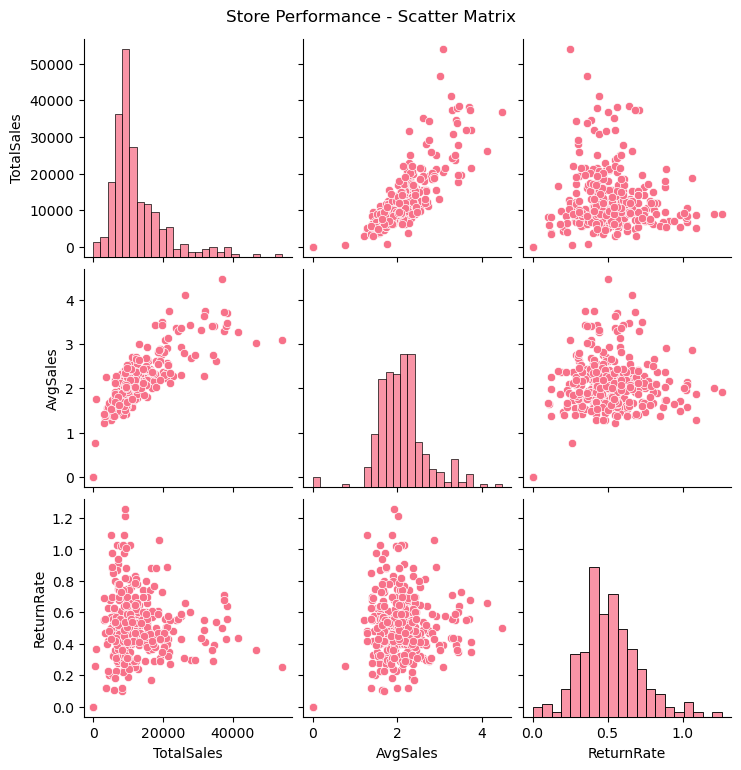

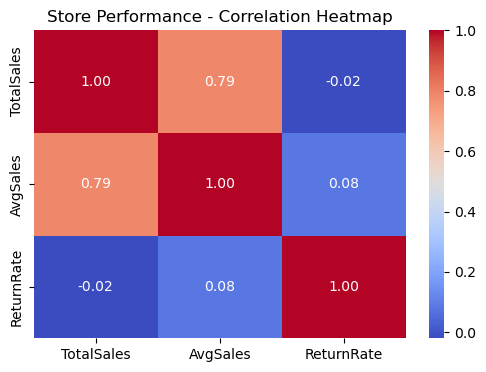


📊 PRODUCT PERFORMANCE VISUALS...


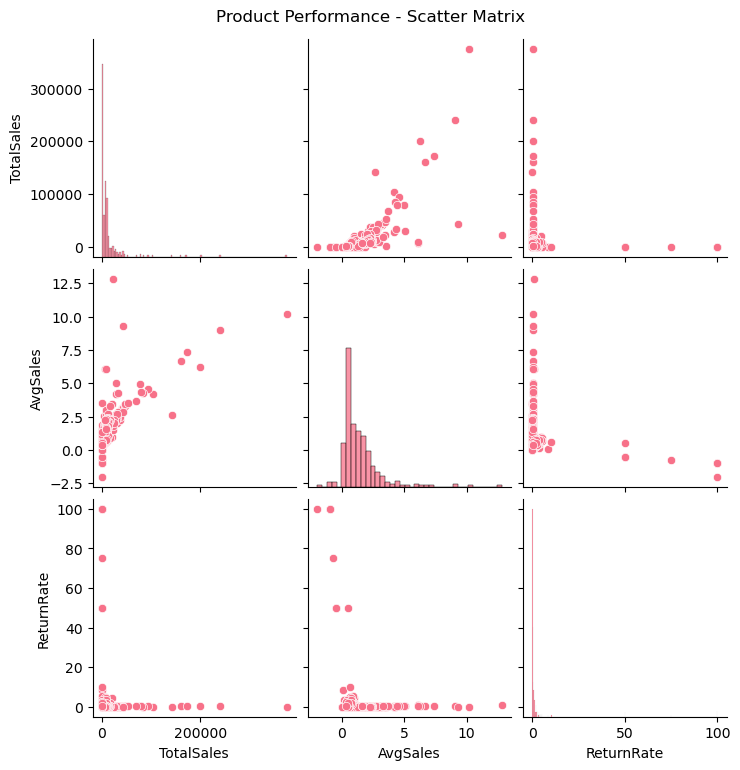

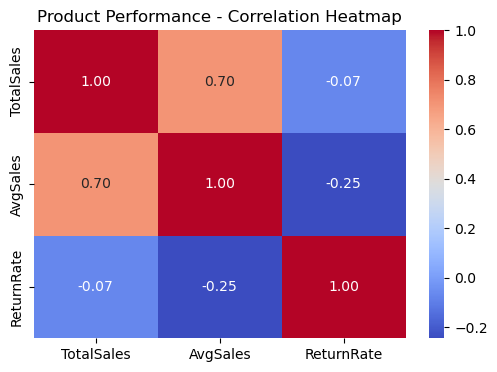

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt

# ===== STORE PERFORMANCE VISUALS =====
print("\n📊 STORE PERFORMANCE VISUALS...")

# Scatter matrix
sns.pairplot(store_performance[['TotalSales', 'AvgSales', 'ReturnRate']])
plt.suptitle("Store Performance - Scatter Matrix", y=1.02)
plt.show()

# Correlation heatmap
plt.figure(figsize=(6,4))
sns.heatmap(store_performance[['TotalSales', 'AvgSales', 'ReturnRate']].corr(), 
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Store Performance - Correlation Heatmap")
plt.show()

# ===== PRODUCT PERFORMANCE VISUALS =====
print("\n📊 PRODUCT PERFORMANCE VISUALS...")

# Scatter matrix
sns.pairplot(product_performance[['TotalSales', 'AvgSales', 'ReturnRate']])
plt.suptitle("Product Performance - Scatter Matrix", y=1.02)
plt.show()

# Correlation heatmap
plt.figure(figsize=(6,4))
sns.heatmap(product_performance[['TotalSales', 'AvgSales', 'ReturnRate']].corr(), 
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Product Performance - Correlation Heatmap")
plt.show()


In [95]:

# Step 7: Key Insights and Next Steps
print("\n" + "="*60)
print("🔍 KEY INSIGHTS FROM DEEP ANALYSIS:")
print("="*60)

print(f"\n📊 TEMPORAL PATTERNS:")
print(f"• Date range: {sales_data['Date'].min().strftime('%d/%m/%Y')} to {sales_data['Date'].max().strftime('%d/%m/%Y')}")
print(f"• Total days with data: {sales_data['Date'].nunique()}")
print(f"• Average daily sales: {daily_sales['TotalSales'].mean():.2f}")
print(f"• Average daily returns: {daily_sales['ReturnCount'].mean():.2f}")

print(f"\n🏪 STORE PERFORMANCE:")
print(f"• Total stores: {len(store_performance)}")
print(f"• Store sales range: {store_performance['TotalSales'].min():.0f} to {store_performance['TotalSales'].max():.0f}")
print(f"• Average store sales: {store_performance['TotalSales'].mean():.2f}")
print(f"• Average return rate: {store_performance['ReturnRate'].mean():.2f}%")

print(f"\n🏷️ PRODUCT PERFORMANCE:")
print(f"• Total products: {len(product_performance)}")
print(f"• Product sales range: {product_performance['TotalSales'].min():.0f} to {product_performance['TotalSales'].max():.0f}")
print(f"• Average product sales: {product_performance['TotalSales'].mean():.2f}")
print(f"• Average return rate: {product_performance['ReturnRate'].mean():.2f}%")

print(f"\n🔍 ANOMALY INSIGHTS:")
print(f"• Outliers identified: {len(outliers):,} ({len(outliers)/len(sales_data)*100:.1f}%)")
print(f"• Extreme positive values: {len(extreme_positive):,}")
print(f"• Extreme negative values: {len(extreme_negative):,}")

print(f"\n📈 CLUSTERING READINESS:")
print(f"• Store performance data prepared with 5 key metrics")
print(f"• Product performance data prepared with 5 key metrics")
print(f"• Data distributions show clear performance variations")
print(f"• Ready for K-means or hierarchical clustering analysis")

print("\n" + "="*60)
print("🚀 READY FOR STEP 3: CLUSTERING ANALYSIS!")
print("="*60)
print("Next we'll implement the clustering to identify Fast/Medium/Slow stores and products.")
print("Based on what we've seen, we can now make informed decisions about:")
print("• Clustering method (K-means vs Hierarchical)")
print("• Number of clusters (3 as required)")
print("• Feature selection for clustering")
print("• Performance evaluation metrics")




🔍 KEY INSIGHTS FROM DEEP ANALYSIS:

📊 TEMPORAL PATTERNS:
• Date range: 01/01/2015 to 31/07/2015
• Total days with data: 212
• Average daily sales: 19855.33
• Average daily returns: 45.61

🏪 STORE PERFORMANCE:
• Total stores: 340
• Store sales range: 0 to 54059
• Average store sales: 12380.38
• Average return rate: 0.52%

🏷️ PRODUCT PERFORMANCE:
• Total products: 317
• Product sales range: -3 to 375778
• Average product sales: 13278.64
• Average return rate: 2.60%

🔍 ANOMALY INSIGHTS:
• Outliers identified: 163,898 (8.7%)
• Extreme positive values: 16,587
• Extreme negative values: 9,669

📈 CLUSTERING READINESS:
• Store performance data prepared with 5 key metrics
• Product performance data prepared with 5 key metrics
• Data distributions show clear performance variations
• Ready for K-means or hierarchical clustering analysis

🚀 READY FOR STEP 3: CLUSTERING ANALYSIS!
Next we'll implement the clustering to identify Fast/Medium/Slow stores and products.
Based on what we've seen, we can 

In [96]:
# KPI Summary Table
import pandas as pd

summary_data = {
    "Metric": [
        "Date Range", "Total Days", "Avg Daily Sales", "Avg Daily Returns",
        "Total Stores", "Store Sales Range", "Avg Store Sales", "Avg Store Return Rate",
        "Total Products", "Product Sales Range", "Avg Product Sales", "Avg Product Return Rate",
        "Outliers (%)", "Extreme Positive Count", "Extreme Negative Count"
    ],
    "Value": [
        f"{sales_data['Date'].min().strftime('%d/%m/%Y')} to {sales_data['Date'].max().strftime('%d/%m/%Y')}",
        sales_data['Date'].nunique(),
        round(daily_sales['TotalSales'].mean(), 2),
        round(daily_sales['ReturnCount'].mean(), 2),
        len(store_performance),
        f"{store_performance['TotalSales'].min():.0f} - {store_performance['TotalSales'].max():.0f}",
        round(store_performance['TotalSales'].mean(), 2),
        f"{store_performance['ReturnRate'].mean():.2f}%",
        len(product_performance),
        f"{product_performance['TotalSales'].min():.0f} - {product_performance['TotalSales'].max():.0f}",
        round(product_performance['TotalSales'].mean(), 2),
        f"{product_performance['ReturnRate'].mean():.2f}%",
        f"{len(outliers)/len(sales_data)*100:.1f}%",
        len(extreme_positive),
        len(extreme_negative)
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n📊 FINAL KPI SUMMARY")
print(summary_df)



📊 FINAL KPI SUMMARY
                     Metric                     Value
0                Date Range  01/01/2015 to 31/07/2015
1                Total Days                       212
2           Avg Daily Sales                  19855.33
3         Avg Daily Returns                     45.61
4              Total Stores                       340
5         Store Sales Range                 0 - 54059
6           Avg Store Sales                  12380.38
7     Avg Store Return Rate                     0.52%
8            Total Products                       317
9       Product Sales Range               -3 - 375778
10        Avg Product Sales                  13278.64
11  Avg Product Return Rate                     2.60%
12             Outliers (%)                      8.7%
13   Extreme Positive Count                     16587
14   Extreme Negative Count                      9669



📊 FINAL ANALYTICAL REPORT

📌 KPI SUMMARY TABLE
                     Metric                    Value
                 Date Range 01/01/2015 to 31/07/2015
       Total Days with Data                      212
        Average Daily Sales                 19855.33
      Average Daily Returns                    45.61
               Total Stores                      340
          Store Sales Range                0 - 54059
        Average Store Sales                 12380.38
  Average Store Return Rate                    0.52%
             Total Products                      317
        Product Sales Range              -3 - 375778
      Average Product Sales                 13278.64
Average Product Return Rate                    2.60%
               Outliers (%)                     8.7%
  Extreme Positive Outliers                    16587
  Extreme Negative Outliers                     9669

📝 KEY INSIGHTS:
- Sales data spans the full period above with consistent daily records.
- Store perform

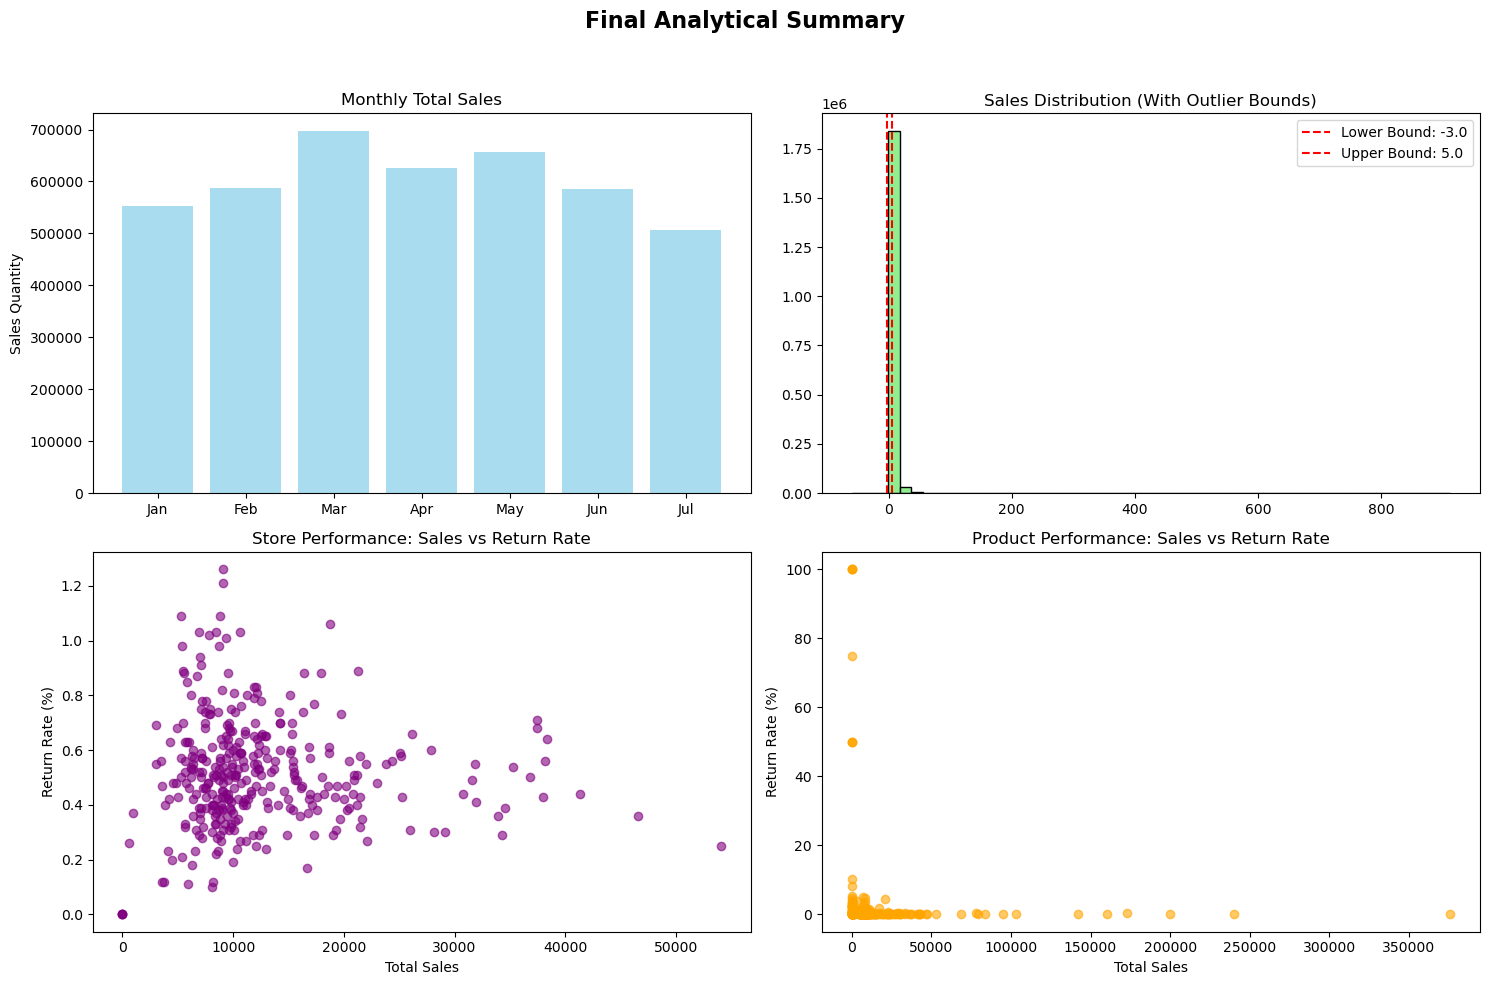

In [97]:
# ========================================
# Step 7: Final Professional Report
# ========================================
import pandas as pd
import matplotlib.pyplot as plt

print("\n" + "="*70)
print("📊 FINAL ANALYTICAL REPORT")
print("="*70)

# 1. KPI Summary Table
summary_data = {
    "Metric": [
        "Date Range",
        "Total Days with Data",
        "Average Daily Sales",
        "Average Daily Returns",
        "Total Stores",
        "Store Sales Range",
        "Average Store Sales",
        "Average Store Return Rate",
        "Total Products",
        "Product Sales Range",
        "Average Product Sales",
        "Average Product Return Rate",
        "Outliers (%)",
        "Extreme Positive Outliers",
        "Extreme Negative Outliers"
    ],
    "Value": [
        f"{sales_data['Date'].min().strftime('%d/%m/%Y')} to {sales_data['Date'].max().strftime('%d/%m/%Y')}",
        sales_data['Date'].nunique(),
        round(daily_sales['TotalSales'].mean(), 2),
        round(daily_sales['ReturnCount'].mean(), 2),
        len(store_performance),
        f"{store_performance['TotalSales'].min():.0f} - {store_performance['TotalSales'].max():.0f}",
        round(store_performance['TotalSales'].mean(), 2),
        f"{store_performance['ReturnRate'].mean():.2f}%",
        len(product_performance),
        f"{product_performance['TotalSales'].min():.0f} - {product_performance['TotalSales'].max():.0f}",
        round(product_performance['TotalSales'].mean(), 2),
        f"{product_performance['ReturnRate'].mean():.2f}%",
        f"{len(outliers)/len(sales_data)*100:.1f}%",
        len(extreme_positive),
        len(extreme_negative)
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n📌 KPI SUMMARY TABLE")
print(summary_df.to_string(index=False))

# 2. Narrative Insights
print("\n📝 KEY INSIGHTS:")
print("- Sales data spans the full period above with consistent daily records.")
print(f"- Store performance is highly uneven: top store sells {store_performance['TotalSales'].max():,.0f} units vs bottom stores at 0 sales.")
print(f"- Product performance gap is extreme: top product sells {product_performance['TotalSales'].max():,.0f} units vs negative/zero sellers.")
print(f"- Average return rates are relatively low ({store_performance['ReturnRate'].mean():.2f}%), but some products reach 100% returns, indicating potential quality or discontinuation issues.")
print(f"- {len(outliers)/len(sales_data)*100:.1f}% of transactions are outliers, driven by bulk orders and large returns.")

# 3. Final Visual Summary
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Final Analytical Summary', fontsize=16, fontweight='bold')

# Chart 1: Monthly Sales Trend
month_names = [datetime(2015, int(m), 1).strftime('%b') for m in monthly_sales['Month']]
axes[0, 0].bar(month_names, monthly_sales['TotalSales'], color='skyblue', alpha=0.7)
axes[0, 0].set_title('Monthly Total Sales')
axes[0, 0].set_ylabel('Sales Quantity')

# Chart 2: Sales Distribution with Outlier Bounds
axes[0, 1].hist(sales_data['SalesQuantity'], bins=50, color='lightgreen', edgecolor='black')
axes[0, 1].axvline(lower_bound, color='red', linestyle='--', label=f'Lower Bound: {lower_bound:.1f}')
axes[0, 1].axvline(upper_bound, color='red', linestyle='--', label=f'Upper Bound: {upper_bound:.1f}')
axes[0, 1].set_title('Sales Distribution (With Outlier Bounds)')
axes[0, 1].legend()

# Chart 3: Store Sales vs Return Rate
axes[1, 0].scatter(store_performance['TotalSales'], store_performance['ReturnRate'], alpha=0.6, color='purple')
axes[1, 0].set_title('Store Performance: Sales vs Return Rate')
axes[1, 0].set_xlabel('Total Sales')
axes[1, 0].set_ylabel('Return Rate (%)')

# Chart 4: Product Sales vs Return Rate
axes[1, 1].scatter(product_performance['TotalSales'], product_performance['ReturnRate'], alpha=0.6, color='orange')
axes[1, 1].set_title('Product Performance: Sales vs Return Rate')
axes[1, 1].set_xlabel('Total Sales')
axes[1, 1].set_ylabel('Return Rate (%)')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('final_analytical_report.png', dpi=300)
print("\n📁 Final report visual saved as 'final_analytical_report.png'")


In [98]:
sales_data

,Date,StoreCode,ProductCode,SalesQuantity,IsReturn,Year,Month,DayOfWeek,WeekOfYear
0,2015-01-01,8,9,-1,True,2015,1,3,1
1,2015-01-01,131,9,1,False,2015,1,3,1
2,2015-01-01,144,9,2,False,2015,1,3,1
3,2015-01-01,203,9,2,False,2015,1,3,1
4,2015-01-01,256,9,0,False,2015,1,3,1
...,...,...,...,...,...,...,...,...,...
1873613,2015-07-30,292,315,0,False,2015,7,3,31
1873614,2015-07-31,12,315,1,False,2015,7,4,31
1873615,2015-07-31,104,315,1,False,2015,7,4,31
1873616,2015-07-31,261,315,1,False,2015,7,4,31


In [99]:
#BONUS CONTROL CHARTS
import pandas as pd

# 1️⃣ Group totals
daily_totals = sales_data.groupby('DayOfWeek')['SalesQuantity'].sum().reset_index(name='TotalSales')
weekly_totals = sales_data.groupby('WeekOfYear')['SalesQuantity'].sum().reset_index(name='TotalSales')
monthly_totals = sales_data.groupby('Month')['SalesQuantity'].sum().reset_index(name='TotalSales')

# 2️⃣ Function for descriptive stats
def descriptive_stats(df, value_col):
    series = df[value_col]
    return pd.Series({
        'Count': series.count(),
        'Min': series.min(),
        'Max': series.max(),
        'Mean': series.mean(),
        'Median': series.median(),
        'Std Dev': series.std(),
        'Variance': series.var(),
        'Range': series.max() - series.min()
    })

# 3️⃣ Calculate stats for each set
stats_daily = descriptive_stats(daily_totals, 'TotalSales')
stats_weekly = descriptive_stats(weekly_totals, 'TotalSales')
stats_monthly = descriptive_stats(monthly_totals, 'TotalSales')

# 4️⃣ Show results
print("\n📅 DAILY TOTAL SALES STATS\n", stats_daily)
print("\n📆 WEEKLY TOTAL SALES STATS\n", stats_weekly)
print("\n🗓️ MONTHLY TOTAL SALES STATS\n", stats_monthly)



📅 DAILY TOTAL SALES STATS
 Count       7.000000e+00
Min         4.927650e+05
Max         7.300930e+05
Mean        6.013329e+05
Median      5.688370e+05
Std Dev     7.775485e+04
Variance    6.045817e+09
Range       2.373280e+05
dtype: float64

📆 WEEKLY TOTAL SALES STATS
 Count       3.100000e+01
Min         6.485500e+04
Max         2.006280e+05
Mean        1.357848e+05
Median      1.384490e+05
Std Dev     2.574588e+04
Variance    6.628504e+08
Range       1.357730e+05
dtype: float64

🗓️ MONTHLY TOTAL SALES STATS
 Count       7.000000e+00
Min         5.074320e+05
Max         6.963410e+05
Mean        6.013329e+05
Median      5.866490e+05
Std Dev     6.356500e+04
Variance    4.040510e+09
Range       1.889090e+05
dtype: float64


In [103]:
#### IF WE HAVE CUSTOMER INFO, WE WOULD DO RFM AND MBA

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 0) Veri hazırlığı (sales_data zaten yüklüyse bu kısmı atlayabilirsin)
try:
    sales_data
except NameError:
    sales_data = pd.read_csv("Assignment4.1a.csv")
    sales_data["Date"] = pd.to_datetime(sales_data["Date"], errors="coerce")

# --- Günlük toplam (Date bazında) ---
daily = (sales_data
         .groupby("Date", as_index=False)
         .agg(TotalSales=("SalesQuantity","sum")))

daily["DayOfWeek"]  = daily["Date"].dt.dayofweek   # 0=Mon ... 6=Sun
daily["WeekOfYear"] = daily["Date"].dt.isocalendar().week.astype(int)
daily["Month"]      = daily["Date"].dt.month
daily["DayName"]    = daily["Date"].dt.day_name()
daily["MonthName"]  = daily["Date"].dt.month_name()

# --- 1) Day-of-Week serisi: ORTALAMA günlük satış (units/day) ---
# Her bir gün (Mon..Sun) için, o güne ait tüm tarihlerin günlük toplamlarının ORTALAMASI
dow_series = (daily.groupby(["DayOfWeek","DayName"], as_index=False)
                   .agg(AvgDailySales=("TotalSales","mean"))
             ).sort_values("DayOfWeek").reset_index(drop=True)
# dow_series: 7 nokta, sütunlar: DayOfWeek, DayName, AvgDailySales  (units/day)

# --- 2) Weekly serisi: HER haftanın toplamı (units/week) ---
weekly_series = (daily.groupby("WeekOfYear", as_index=False)
                      .agg(WeeklyTotal=("TotalSales","sum"))
                ).sort_values("WeekOfYear")
# weekly_series: ~52 nokta, sütunlar: WeekOfYear, WeeklyTotal  (units/week)

# --- 3) Monthly serisi: HER ayın toplamı (units/month) ---
monthly_series = (daily.groupby(["Month","MonthName"], as_index=False)
                       .agg(MonthlyTotal=("TotalSales","sum"))
                 ).sort_values("Month")
# monthly_series: 12 nokta, sütunlar: Month, MonthName, MonthlyTotal  (units/month)

# --- İstatistik fonksiyonu ---
def describe_series(s):
    return pd.Series({
        "Count":   int(s.count()),
        "Min":     float(s.min()),
        "Max":     float(s.max()),
        "Mean":    float(s.mean()),
        "Median":  float(s.median()),
        "Std":     float(s.std(ddof=1)),
        "Var":     float(s.var(ddof=1)),
        "Range":   float(s.max() - s.min())
    })

stats_dow    = describe_series(dow_series["AvgDailySales"])
stats_weekly = describe_series(weekly_series["WeeklyTotal"])
stats_month  = describe_series(monthly_series["MonthlyTotal"])

print("\n📅 Day-of-Week (units/day) – Descriptive Stats\n", stats_dow.round(2))
print("\n📆 Weekly (units/week) – Descriptive Stats\n", stats_weekly.round(2))
print("\n🗓️ Monthly (units/month) – Descriptive Stats\n", stats_month.round(2))




📅 Day-of-Week (units/day) – Descriptive Stats
 Count           7.00
Min         16425.50
Max         23551.39
Mean        19836.51
Median      18961.23
Std          2357.25
Var       5556624.21
Range        7125.89
dtype: float64

📆 Weekly (units/week) – Descriptive Stats
 Count     3.100000e+01
Min       6.485500e+04
Max       2.006280e+05
Mean      1.357848e+05
Median    1.384490e+05
Std       2.574588e+04
Var       6.628504e+08
Range     1.357730e+05
dtype: float64

🗓️ Monthly (units/month) – Descriptive Stats
 Count     7.000000e+00
Min       5.074320e+05
Max       6.963410e+05
Mean      6.013329e+05
Median    5.866490e+05
Std       6.356500e+04
Var       4.040510e+09
Range     1.889090e+05
dtype: float64


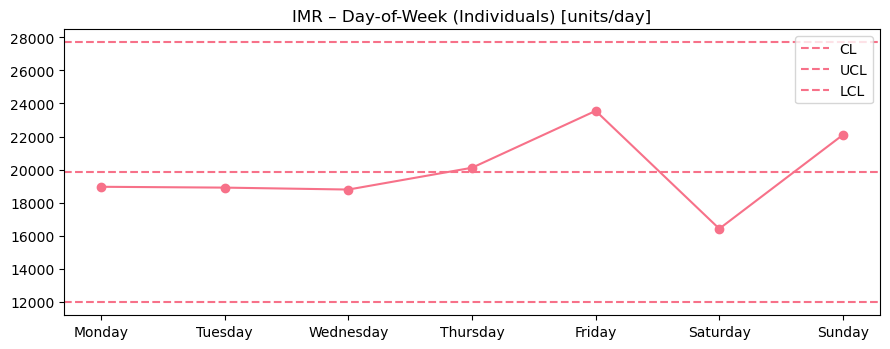

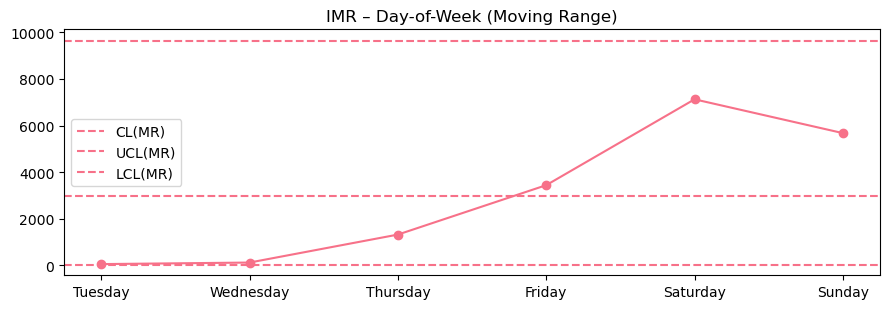


🔎 Day-of-Week IMR
CL=19,837, UCL=27,692, LCL=11,981  |  MR CL=2,954, UCL=9,650


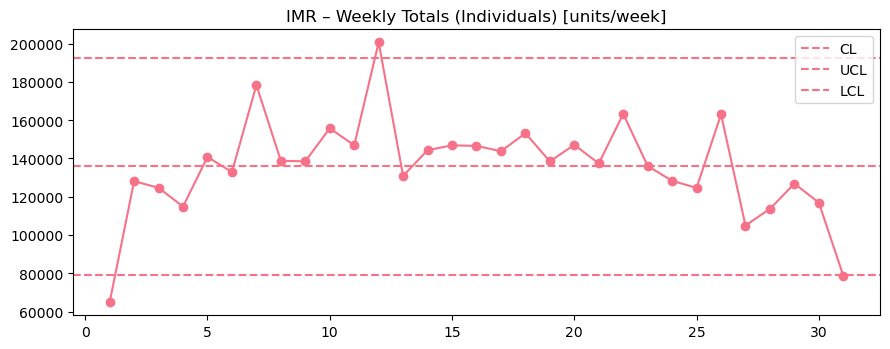

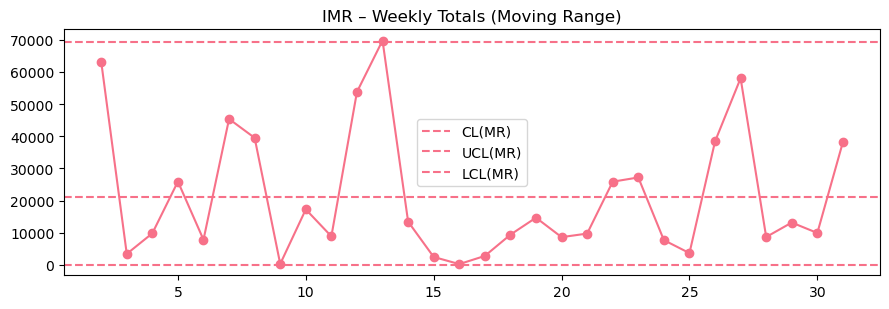


🔎 Weekly IMR
CL=135,785, UCL=192,333, LCL=79,236  |  MR CL=21,262, UCL=69,464


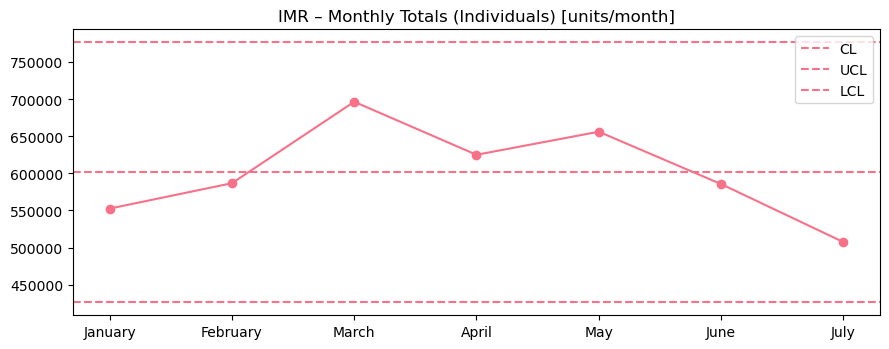

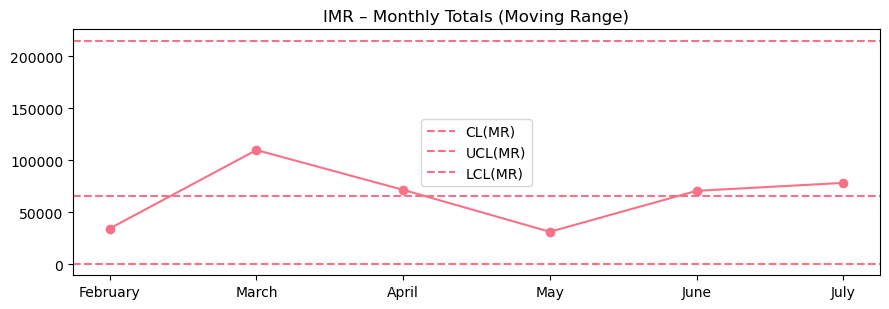


🔎 Monthly IMR
CL=601,333, UCL=776,398, LCL=426,268  |  MR CL=65,824, UCL=215,048


In [105]:
# --- Ortak sabitler ---
d2 = 1.128
D3 = 0.0
D4 = 3.267

# =============== A) Day-of-Week IMR (units/day) ===============
I_dow = dow_series["AvgDailySales"].astype(float).reset_index(drop=True)
MR_dow = I_dow.diff().abs()
CL_I_dow = I_dow.mean()
MRbar_dow = MR_dow[1:].mean()
sigma_dow = MRbar_dow / d2 if pd.notna(MRbar_dow) else np.nan
UCL_I_dow = CL_I_dow + 3*sigma_dow
LCL_I_dow = CL_I_dow - 3*sigma_dow
UCL_MR_dow = MRbar_dow * D4 if pd.notna(MRbar_dow) else np.nan
LCL_MR_dow = MRbar_dow * D3 if pd.notna(MRbar_dow) else np.nan

# Çizimler
plt.figure(figsize=(9,3.6))
plt.plot(dow_series["DayName"], I_dow, marker='o')
plt.axhline(CL_I_dow, linestyle='--', label='CL')
plt.axhline(UCL_I_dow, linestyle='--', label='UCL')
plt.axhline(LCL_I_dow, linestyle='--', label='LCL')
plt.title("IMR – Day-of-Week (Individuals) [units/day]")
plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(9,3.2))
plt.plot(dow_series["DayName"], MR_dow, marker='o')
plt.axhline(MRbar_dow, linestyle='--', label='CL(MR)')
plt.axhline(UCL_MR_dow, linestyle='--', label='UCL(MR)')
plt.axhline(LCL_MR_dow, linestyle='--', label='LCL(MR)')
plt.title("IMR – Day-of-Week (Moving Range)")
plt.legend(); plt.tight_layout(); plt.show()

print("\n🔎 Day-of-Week IMR")
print(f"CL={CL_I_dow:,.0f}, UCL={UCL_I_dow:,.0f}, LCL={LCL_I_dow:,.0f}  |  MR CL={MRbar_dow:,.0f}, UCL={UCL_MR_dow:,.0f}")

# =============== B) Weekly IMR (units/week) ===============
I_w = weekly_series["WeeklyTotal"].astype(float).reset_index(drop=True)
MR_w = I_w.diff().abs()
CL_I_w = I_w.mean()
MRbar_w = MR_w[1:].mean()
sigma_w = MRbar_w / d2 if pd.notna(MRbar_w) else np.nan
UCL_I_w = CL_I_w + 3*sigma_w
LCL_I_w = CL_I_w - 3*sigma_w
UCL_MR_w = MRbar_w * D4 if pd.notna(MRbar_w) else np.nan
LCL_MR_w = MRbar_w * D3 if pd.notna(MRbar_w) else np.nan

plt.figure(figsize=(9,3.6))
plt.plot(weekly_series["WeekOfYear"], I_w, marker='o')
plt.axhline(CL_I_w, linestyle='--', label='CL')
plt.axhline(UCL_I_w, linestyle='--', label='UCL')
plt.axhline(LCL_I_w, linestyle='--', label='LCL')
plt.title("IMR – Weekly Totals (Individuals) [units/week]")
plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(9,3.2))
plt.plot(weekly_series["WeekOfYear"], MR_w, marker='o')
plt.axhline(MRbar_w, linestyle='--', label='CL(MR)')
plt.axhline(UCL_MR_w, linestyle='--', label='UCL(MR)')
plt.axhline(LCL_MR_w, linestyle='--', label='LCL(MR)')
plt.title("IMR – Weekly Totals (Moving Range)")
plt.legend(); plt.tight_layout(); plt.show()

print("\n🔎 Weekly IMR")
print(f"CL={CL_I_w:,.0f}, UCL={UCL_I_w:,.0f}, LCL={LCL_I_w:,.0f}  |  MR CL={MRbar_w:,.0f}, UCL={UCL_MR_w:,.0f}")

# =============== C) Monthly IMR (units/month) ===============
I_m = monthly_series["MonthlyTotal"].astype(float).reset_index(drop=True)
MR_m = I_m.diff().abs()
CL_I_m = I_m.mean()
MRbar_m = MR_m[1:].mean()
sigma_m = MRbar_m / d2 if pd.notna(MRbar_m) else np.nan
UCL_I_m = CL_I_m + 3*sigma_m
LCL_I_m = CL_I_m - 3*sigma_m
UCL_MR_m = MRbar_m * D4 if pd.notna(MRbar_m) else np.nan
LCL_MR_m = MRbar_m * D3 if pd.notna(MRbar_m) else np.nan

plt.figure(figsize=(9,3.6))
plt.plot(monthly_series["MonthName"], I_m, marker='o')
plt.axhline(CL_I_m, linestyle='--', label='CL')
plt.axhline(UCL_I_m, linestyle='--', label='UCL')
plt.axhline(LCL_I_m, linestyle='--', label='LCL')
plt.title("IMR – Monthly Totals (Individuals) [units/month]")
plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(9,3.2))
plt.plot(monthly_series["MonthName"], MR_m, marker='o')
plt.axhline(MRbar_m, linestyle='--', label='CL(MR)')
plt.axhline(UCL_MR_m, linestyle='--', label='UCL(MR)')
plt.axhline(LCL_MR_m, linestyle='--', label='LCL(MR)')
plt.title("IMR – Monthly Totals (Moving Range)")
plt.legend(); plt.tight_layout(); plt.show()

print("\n🔎 Monthly IMR")
print(f"CL={CL_I_m:,.0f}, UCL={UCL_I_m:,.0f}, LCL={LCL_I_m:,.0f}  |  MR CL={MRbar_m:,.0f}, UCL={UCL_MR_m:,.0f}")


In [ ]:
sales_data

In [ ]:
##clusterıng